<a href="https://colab.research.google.com/github/lamtfey11/Laba_1_Lisov_IDB_23_13/blob/main/LR1_2_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### О задании
В этом задании мы попытаемся научиться анализировать данные и выделять из них полезные признаки. Мы также научимся пользоваться `seaborn` и `sklearn`, а заодно привыкнем к основным понятиям машинного обучения.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Проверяющий имеет право снизить оценку за неэффективную реализацию или неопрятные графики.

**Обратите внимание**, что в каждом разделе  задания есть оцениваниемые задачи и есть вопросы. Вопросы дополняют задачи и направлены на то, чтобы проинтерпретировать или обосновать происходящее. Код без интерпретации не имеет смысла, поэтому отвечать на вопросы обязательно — за отсутствие ответов мы будем снижать баллы за задачи. Если вы ответите на вопросы, но не напишете корректный код к соответствующим оцениваемым задачам, то баллы за такое выставлены не будут.


Оценка: xx.

В этом ноутбуке используется библиотека `folium` для визуализации карт. Она работает в google colab!

In [40]:
!pip install folium

In [41]:
import folium

m = folium.Map(location=(55.7522200, 37.6155600), zoom_start=10)

m

Если вы всё сделали правильно, то выше должна открыться карта Москвы.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style="darkgrid")

np.random.seed(0)

## Часть 0. Подготовка (1 балл)

**Задание 1 (1 балл)**. Мы будем работать с данными из соревнования [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), в котором нужно было предсказать длительность поездки на такси. Скачайте обучающую выборку из этого соревнования и загрузите ее:

In [43]:
df = pd.read_csv('train.csv')
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


| Колонка                | Значение                                                                                                      |
| ---------------------- | ------------------------------------------------------------------------------------------------------------- |
| **id**                 | Уникальный идентификатор поездки.                                                                             |
| **vendor_id**          | ID компании такси/поставщика услуги (например, две разные службы такси в NYC).                                |
| **pickup_datetime**    | Дата и время начала поездки (когда пассажир сел в такси).                                                     |
| **passenger_count**    | Количество пассажиров в машине.                                                                               |
| **pickup_longitude**   | Долгота места посадки пассажира.                                                                              |
| **pickup_latitude**    | Широта места посадки пассажира.                                                                               |
| **dropoff_longitude**  | Долгота места высадки пассажира.                                                                              |
| **dropoff_latitude**   | Широта места высадки пассажира.                                                                               |
| **store_and_fwd_flag** | Флаг, показывающий, была ли информация о поездке временно сохранена и отправлена позже (`Y` = yes, `N` = no). |
| **trip_duration**      | Длительность поездки в секундах — **целевой параметр, который нужно предсказывать**.                          |


Обратите внимание на колонки `pickup_datetime` и `dropoff_datetime`. `dropoff_datetime` был добавлена организаторами только в обучающую выборку, то есть использовать эту колонку нельзя, давайте удалим ее. В `pickup_datetime` записаны дата и время начала поездки. Чтобы с ней было удобно работать, давайте преобразуем даты в `datetime`-объекты

In [44]:
df.shape

(1458644, 11)

In [45]:
df.drop(columns='dropoff_datetime', inplace=True)
df.shape

(1458644, 10)

In [46]:
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [47]:
df.dtypes

,0
id,object
vendor_id,int64
pickup_datetime,object
passenger_count,int64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
store_and_fwd_flag,object
trip_duration,int64


In [48]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df.dtypes

,0
id,object
vendor_id,int64
pickup_datetime,datetime64[ns]
passenger_count,int64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
store_and_fwd_flag,object
trip_duration,int64


В колонке `trip_duration` записано целевое значение, которое мы хотим предсказывать. Давайте посмотрим на распределение таргета в обучающей выборке. Для этого нарисуйте его гистограмму:

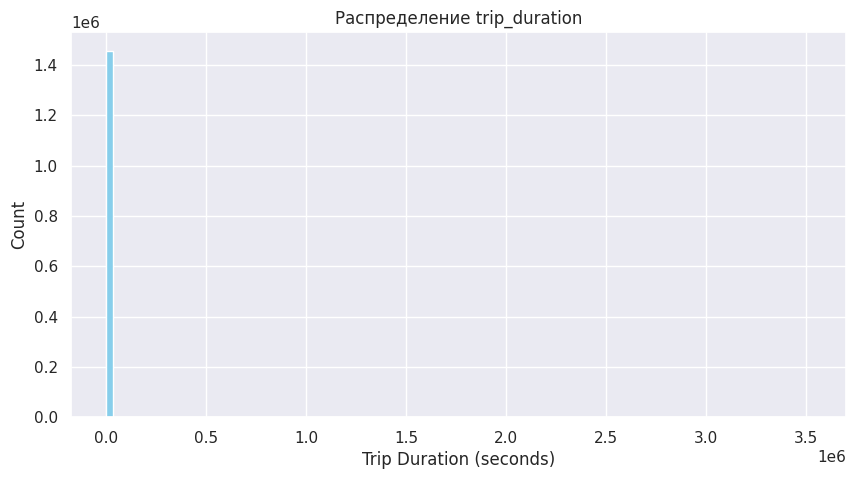

In [49]:
plt.figure(figsize=(10,5))
plt.hist(df['trip_duration'], bins=100, color='skyblue')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Count')
plt.title('Распределение trip_duration')
plt.show()


**Вопрос**: Что можно сказать о целевой переменной по гистограмме её значений?

**Ответ**: я предполагаю, что у меня много маленьких поездок и на их визуализацию влияют длинные поездки "выбросы". Это работает так: из-за длительных поездок моя ось X растягивается, мы видим пик маленьких поездок, но не видим колво больших. Решение есть, и как раз по заданию дальше будет понятно, что решение через логарфим.

В соревновании в качестве метрики качества использовалось RMSLE:
$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$

**Вопрос**: Как вы думаете, почему авторы соревнования выбрали именно RMSLE, а не RMSE?

**Ответ**: RMSLE лучше подходит для времени поездок, потому что он штрафует за относительные ошибки, а не за абсолютные. Ошибка в 5 минут для короткой поездки считается серьезнее, чем та же ошибка в 5 минут для долгой поездки.

**Ремарка форумулы чисто для себя, потому что тема сложная, а так хоть в памяти что-то останется**:
- y_i - настоящее время поездки;
- a(x_i) - предсказанное время поездки;
- log - логарифм сжимает большие числа, где разница для 5 и 10 минут существена, а разница между 60 и 65 минутами нет.



На семинаре мы рассматривали несколько моделей линейной регрессии в `sklearn`, но каждая из них оптимизировала среднеквадратичную ошибку (MSE), а не RMSLE. Давайте проделаем следующий трюк: будем предсказывать не целевую переменную, а ее *логарифм*. Обозначим $\hat{y}_i = \log{(y_i + 1)}$ — модифицированный таргет, а $\hat{a}(x_i)$ — предсказание модели, которая обучалась на $\hat{y}_i$, то есть логарифм таргета. Чтобы предсказать исходное значение, мы можем просто взять экспоненту от нашего предсказания: $a(x_i) = \exp(\hat{a}(x_i)) - 1$.

!Мы заставляем модель думать не "на сколько минут ошибаться", а "во сколько раз ошибаться".

**Вопрос**: Покажите, что оптимизация RMSLE для модели $a$ эквивалентна оптимизации MSE для модели $\hat{a}$.

**Доказательство**: ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
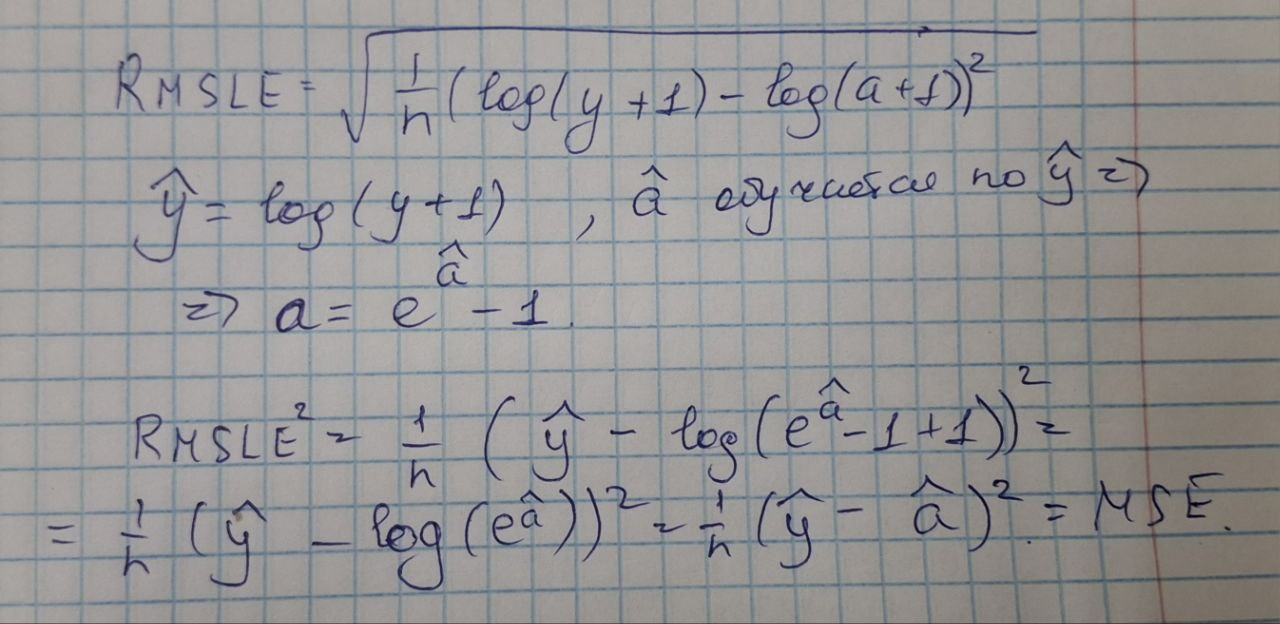

Итак, мы смогли свести задачу оптимизации RMSLE к задаче оптимизации MSE, которую мы умеем решать! Кроме того, у логарифмирования таргета есть еще одно полезное свойство. Чтобы его увидеть, добавьте к нашей выборке колонку `log_trip_duration` (воспользуйтесь `np.log1p`) и нарисуйте гистограмму модифицированного таргета по обучающей выборке. Удалите колонку со старым таргетом.

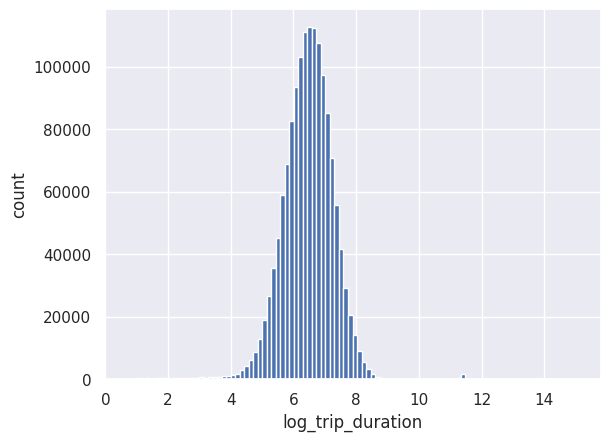

In [50]:
df['log_trip_duration'] = np.log1p(df['trip_duration'].values)
plt.hist(df['log_trip_duration'], bins=100)
plt.xlabel('log_trip_duration')
plt.ylabel('count')
plt.show()

На всякий случай показал график, когда мы работаем с rmsle через mse.
А теперь удалим колонку с таргетом.

In [51]:
df.drop(columns='trip_duration', inplace=True)
display(df.head(), df.shape)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,6.122493
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,6.498282
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,7.661527
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,6.063785
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,6.077642


(1458644, 10)

Чтобы иметь некоторую точку отсчета, давайте посчитаем значение метрики при наилучшем константном предсказании (Наилучшее константное предсказание - это одно число, которое модель всегда предсказывает, независимо от входных данных.):

In [52]:
import math

best_const_log = np.mean(df.log_trip_duration)
print(best_const_log)
best_const = math.e**np.mean(np.log(df.log_trip_duration))
print(best_const)

6.466978409297406
6.413305177556131


## Часть 1. Изучаем `pickup_datetime` (2 балла)

**Задание 2 (0.25 баллов)**. Для начала давайте посмотрим, сколько всего было поездок в каждый из дней. Постройте график зависимости количества поездок от дня в году (например, можно воспользоваться `sns.countplot`):

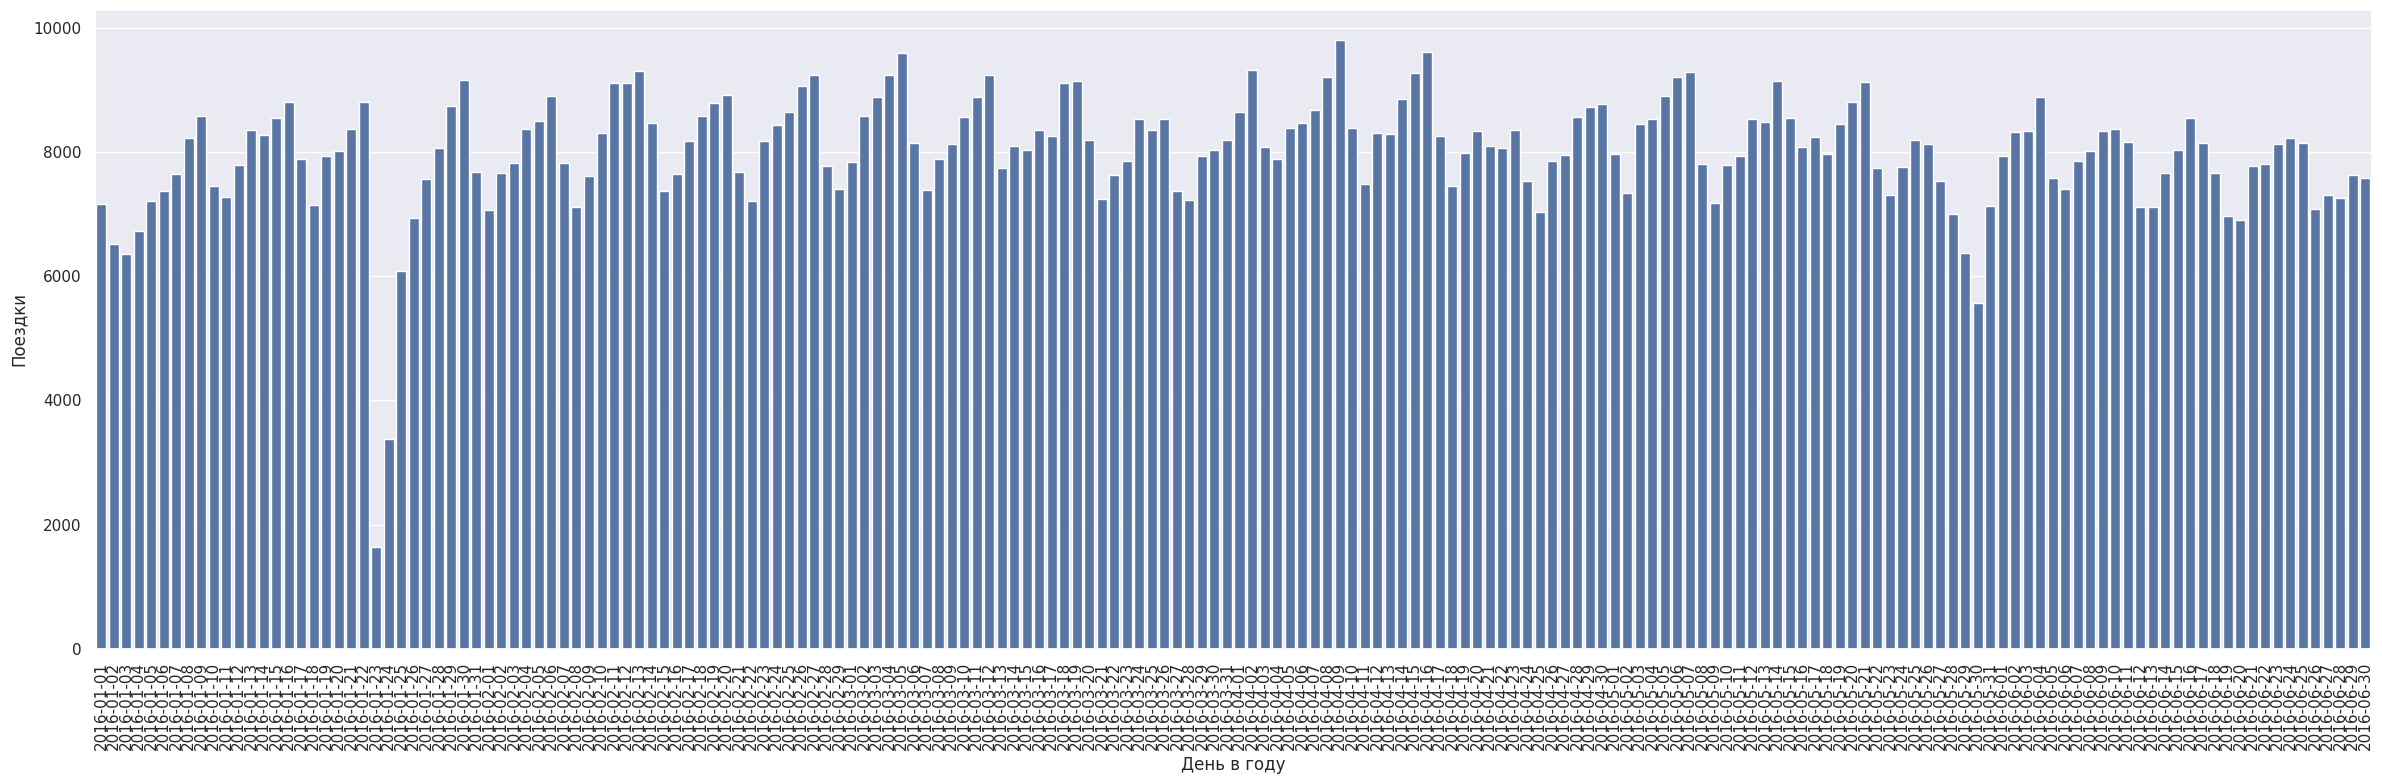

In [53]:
plt.figure(figsize=(24,8))

x = df['pickup_datetime'].dt.date#по оси х у нас будет даты начала поездки без времени

dates_sorted = sorted(x.unique())# Сортируем даты

sns.countplot(x=x, order=dates_sorted)

plt.xlabel('День в году')
plt.ylabel('Поездки')
plt.xticks(rotation=90)
plt.tight_layout()  # Чтобы подписи не обрезались
plt.show()

**Вопрос**: Вы, вероятно, заметили, что на графике есть 2 периода с аномально маленькими количествами поездок. Вычислите, в какие даты происходили эти скачки вниз и найдите информацию о том, что происходило в эти дни в Нью-Йорке.

In [54]:
daily_stats = df.groupby(df['pickup_datetime'].dt.date).size().reset_index(name='count')
daily_stats = daily_stats.sort_values('count')
display(daily_stats)

print("Аномально низкие дни (ниже 1-го процентиля):")
print(daily_stats.head(2))

,pickup_datetime,count
22,2016-01-23,1648
23,2016-01-24,3383
150,2016-05-30,5570
24,2016-01-25,6084
2,2016-01-03,6353
...,...,...
43,2016-02-13,9309
92,2016-04-02,9325
64,2016-03-05,9597
106,2016-04-16,9602


Аномально низкие дни (ниже 1-го процентиля):
   pickup_datetime  count
22      2016-01-23   1648
23      2016-01-24   3383


Нарисуйте графики зависимости количества поездок от дня недели и от часов в сутках (воспользуйтесь `sns.relplot`):

Сначала тогда график по дням недели.

Text(-21.180555555555557, 0.5, 'Кол-во')

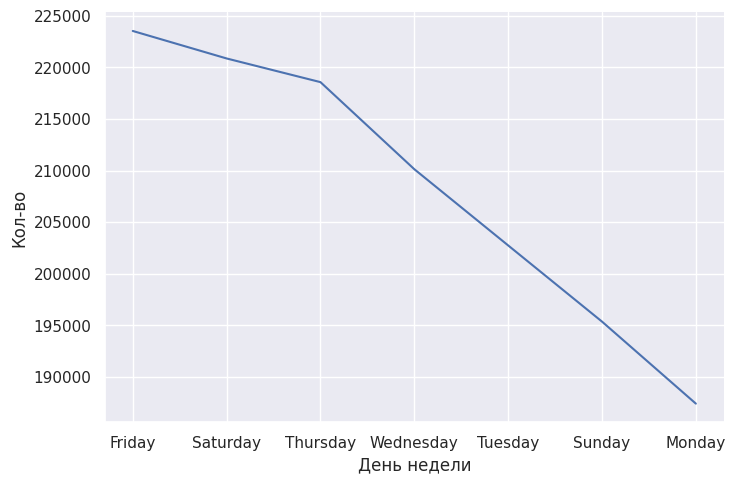

In [55]:
x = df['pickup_datetime'].dt.day_name().value_counts().index # просто находим дни недели и их кол-во (сколько раз попадается каждый из дней недели)
y = df['pickup_datetime'].dt.day_name().value_counts() # тут же просто для оси Y находим кол-во

sns.relplot(x = x, y = y, aspect=1.5, kind = 'line')

plt.xlabel('День недели')
plt.ylabel('Кол-во')

Теперь сделаем график для часов.

Text(-11.555555555555555, 0.5, 'Кол-во')

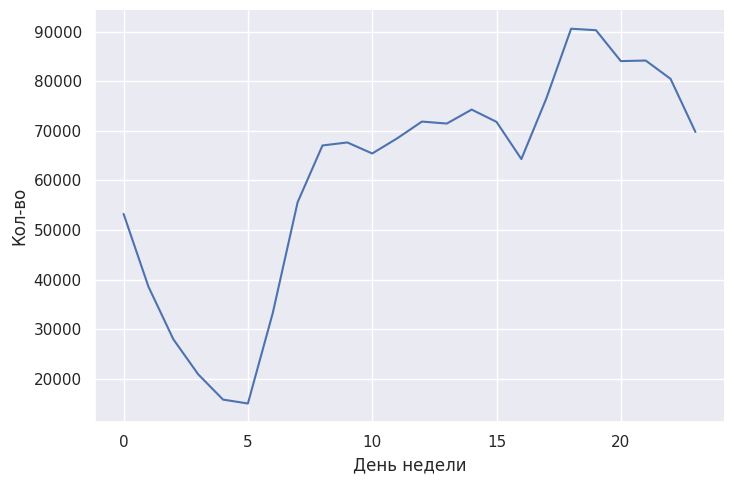

In [56]:
x = df['pickup_datetime'].dt.hour.value_counts().index # просто находим часы и их кол-во (сколько раз попадается каждый из дней недели)
y = df['pickup_datetime'].dt.hour.value_counts() # тут же просто для оси Y находим кол-во

sns.relplot(x = x, y = y, aspect=1.5,kind = 'line')

plt.xlabel('День недели')
plt.ylabel('Кол-во')

**Задание 3 (0.5 баллов)**. Нарисуйте на одном графике зависимости количества поездок от часа в сутках для разных месяцев (разные кривые, соответствующие разным месяцам, окрашивайте в разные цвета, воспользуйтесь `hue` в `sns.relplot`). Аналогично нарисуйте зависимости количества поездок от часа в сутках для разных дней недели.

Создам новые стольбки в датафрейме для визуализации: час, месяц, день недели, день гола.

ахахахахахах, день гола (оставлю).

In [57]:
df['hour'] = df['pickup_datetime'].dt.hour
df['month'] = df['pickup_datetime'].dt.month_name()
df['day_of_week'] = df['pickup_datetime'].dt.day_name()
df['day_of_year'] = df['pickup_datetime'].dt.date
df.head(10)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,hour,month,day_of_week,day_of_year
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,6.122493,17,March,Monday,2016-03-14
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,6.498282,0,June,Sunday,2016-06-12
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,7.661527,11,January,Tuesday,2016-01-19
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,6.063785,19,April,Wednesday,2016-04-06
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,6.077642,13,March,Saturday,2016-03-26
5,id0801584,2,2016-01-30 22:01:40,6,-73.982857,40.742195,-73.992081,40.749184,N,6.095825,22,January,Saturday,2016-01-30
6,id1813257,1,2016-06-17 22:34:59,4,-73.969017,40.757839,-73.957405,40.765896,N,5.834811,22,June,Friday,2016-06-17
7,id1324603,2,2016-05-21 07:54:58,1,-73.969276,40.797779,-73.922470,40.760559,N,7.347300,7,May,Saturday,2016-05-21
8,id1301050,1,2016-05-27 23:12:23,1,-73.999481,40.738400,-73.985786,40.732815,N,5.545177,23,May,Friday,2016-05-27
9,id0012891,2,2016-03-10 21:45:01,1,-73.981049,40.744339,-73.973000,40.789989,N,7.111512,21,March,Thursday,2016-03-10


Text(52.87483333333333, 0.5, 'Кол-во поездок')

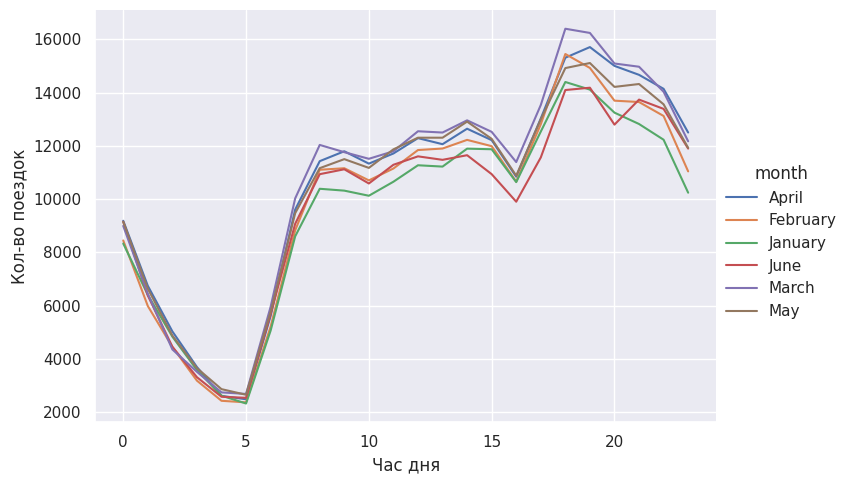

In [58]:
sns.relplot(hue = 'month', x = 'hour', y = 'day_of_week', data = df.groupby(['month', 'hour']).count(), kind = 'line', aspect=1.5)

plt.xlabel('Час дня')
plt.ylabel('Кол-во поездок')

Text(55.71770833333332, 0.5, 'Кол-во')

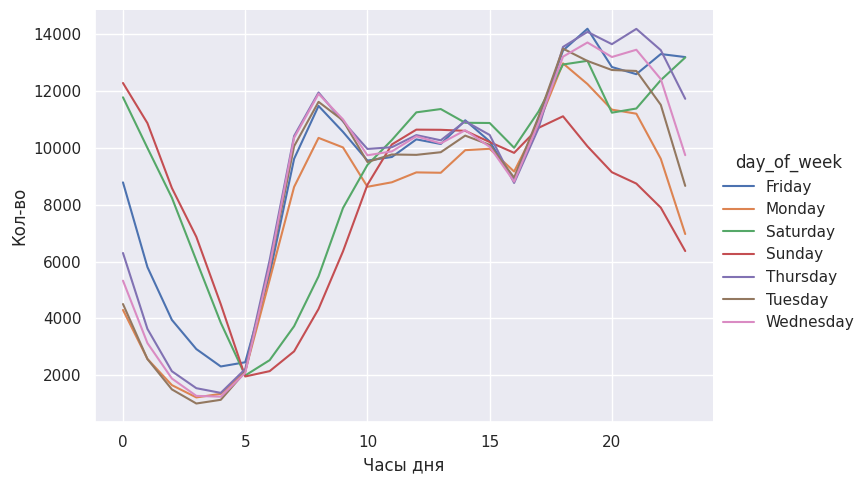

In [59]:
sns.relplot(hue = 'day_of_week', x = 'hour', y = 'month', data = df.groupby(['day_of_week', 'hour']).count(), kind = 'line', aspect=1.5)

plt.xlabel('Часы дня')
plt.ylabel('Кол-во')

пятница

Понедельник

Суббота

Воскресенье

Четверг

Вторник

Среда

**Вопрос**: Какие выводы можно сделать, основываясь на графиках выше? Выделяются ли какие-нибудь дни недели? Месяца? Время суток? С чем это связано?

**Ответ**: ну, месяца не отличаются сильно друг от друга, а вот с днями поинтересней. Сразу в глаза бросается 5 утра, где такси берут мало. В субботу у воскресенье больше поездок до 5 утра, наверное, тусят люди)

**Задание 4 (0.5 баллов)**. Разбейте выборку на обучающую и тестовую в отношении 7:3 (используйте `train_test_split` из `sklearn`). По обучающей выборке нарисуйте график зависимости среднего логарифма времени поездки от дня недели. Затем сделайте то же самое, но для часа в сутках и дня в году.

Тут я разделаю нащ датафрейм на данные для обучения, чтоб потом он смог предсказывать по данным теста.

In [60]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.3)
display(train.shape, test.shape)

(1021050, 14)

(437594, 14)

Теперь пострим график зависимости сред логорифма времени поездки от дня недели:

Text(2.6944444444444446, 0.5, 'log')

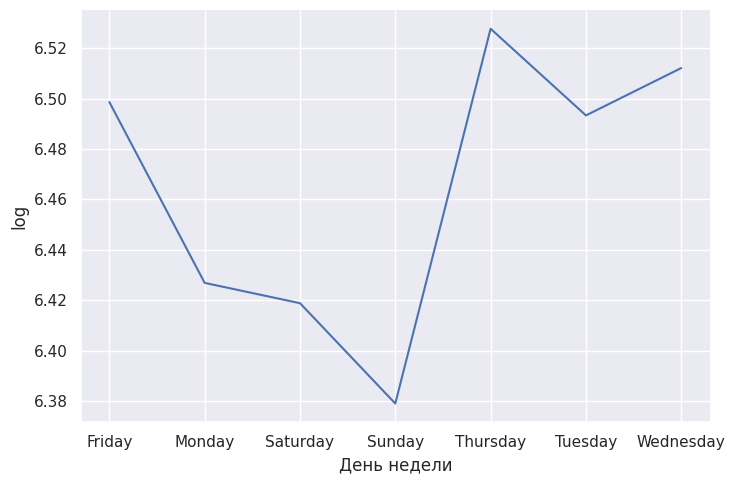

In [61]:
x = train.groupby('day_of_week')['log_trip_duration'].mean().index
y = train.groupby('day_of_week')['log_trip_duration'].mean()

sns.relplot(x = x, y = y, aspect=1.5, kind = 'line')

plt.xlabel('День недели')
plt.ylabel('log')

Теперь пострим график зависимости сред логорифма времени поездки от часа дня:

Text(2.6944444444444446, 0.5, 'log')

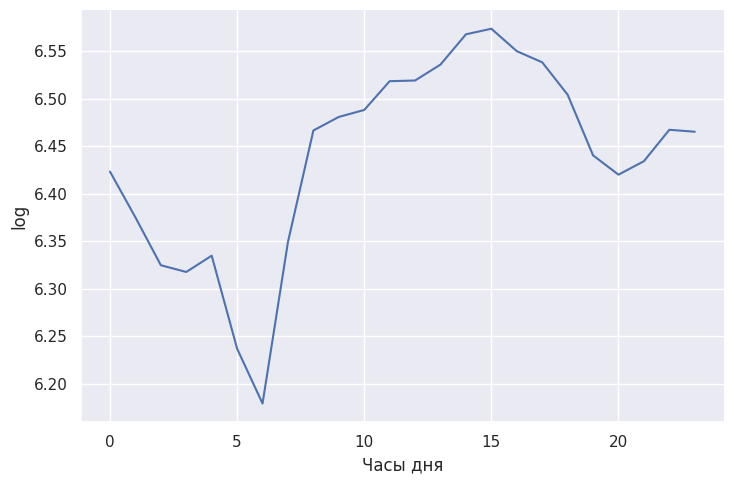

In [62]:
x = train.groupby('hour')['log_trip_duration'].mean().index
y = train.groupby('hour')['log_trip_duration'].mean()

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('Часы дня')
plt.ylabel('log')

Text(12.319444444444445, 0.5, 'log')

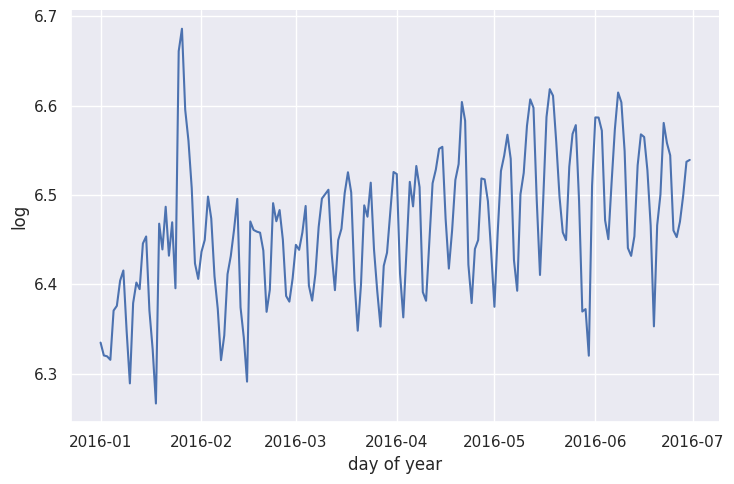

In [63]:
x = train.groupby('day_of_year')['log_trip_duration'].mean().index
y = train.groupby('day_of_year')['log_trip_duration'].mean()

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('day of year')
plt.ylabel('log')

**Вопрос**: Похожи ли графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок? Почему? Что происходит со средним таргетом в те два аномальных периода, что мы видели выше? Почему так происходит? Наблюдаете ли вы какой-нибудь тренд на графике зависимости `log_trip_duration` от номера дня в году?

**Ответ:** График зависимости таргета от часа в сутках похож на график зависимости для количества поездок. Возможно, так произошло, потому что ночью не особо много поездок, а также их длительность оказалась меньше, так как ночью, во-первых, не так много пробок, как днем, во-вторых, люди реже ездят на большое расстояние. Днем же количество поездок возрастает (люди просыпаются), следовательно возникают пробки, что увеличивает продолжительность поездки, и появляется больше заказов на большие расстояния.

С графиком зависимости таргета от дня недели так не сработало. Ну тут сложно вообще придумать, какая может быть зависимость. Единственное, что я придумала: по графикам заметно, что в пятнциу очень много поездок, а также их продолжительность высока; так происходит, потому что люди могут на выходные уезжать за пределы города; однако эта теория ломается в воскресенье, потому что по идее люди должны возвращаться в город, и продолжительность поездок должна вырастать, но этого не происходит. В общем и целом тут никакой зависимости я не заметила.

По графикам зависимости таргета от дня в году можно заметить, что в те два аномальных периода средний таргет очень сильно вырос. Может быть это произошло из-за сторонних факторов в тот день, потому что тогда была снежная буря, и в такую погоду просто не получится быстро передвигаться => среднее время поездки выросло.


Добавьте следующие признаки на основе `pickup_datetime`:
1. День недели
2. Месяц
3. Час
4. Является ли период аномальным (два бинарных признака, соответствующие двум аномальным периодам)
5. Номер дня в году

ВЫше было добавлины в датафрейм день недели, месяц, час.

In [64]:
train['is_bad'] = 0
train.loc[train['pickup_datetime'].dt.date.isin(train['pickup_datetime'].dt.date.value_counts()[-2:].index),'is_bad'] = 1

train['day_of_year'] = train['pickup_datetime'].dt.dayofyear

test['is_bad'] = 0
test.loc[test['pickup_datetime'].dt.date.isin(test['pickup_datetime'].dt.date.value_counts()[-2:].index),'is_bad'] = 1

test['day_of_year'] = test['pickup_datetime'].dt.dayofyear
display(train.head(2), test.head(2))

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,hour,month,day_of_week,day_of_year,is_bad
430252,id2968130,2,2016-02-15 00:52:17,2,-73.934586,40.797016,-73.917397,40.834545,N,6.100319,0,February,Monday,46,0
598829,id2358444,2,2016-03-22 12:04:34,2,-73.957748,40.764500,-73.978706,40.758430,N,7.047517,12,March,Tuesday,82,0


,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,hour,month,day_of_week,day_of_year,is_bad
571578,id2141905,2,2016-03-31 16:04:41,1,-73.971916,40.757042,-73.974663,40.753624,N,4.736198,16,March,Thursday,91,0
1280332,id0996953,2,2016-04-21 21:54:52,2,-73.961891,40.771061,-73.906311,40.908562,N,7.619724,21,April,Thursday,112,0


Итак, мы уже создали некоторое количество признаков.

**Вопрос**: Какие из признаков _стоит рассматривать в этой задаче_   как категориальные, а какие - как численные? Почему?

**Ответ**: Классификация временных признаков для предсказания длительности поездок требует внимательного подхода, учитывающего как математическую природу признаков, так и их смысловое содержание в контексте транспортных закономерностей. День года разумно рассматривать как численный признак, поскольку он обладает естественной линейной последовательностью, позволяющей модели выявлять сезонные тренды и долгосрочные изменения в поведении пассажиров. В отличие от этого, месяц следует считать категориальным признаком, поскольку между отдельными месяцами нет отношений порядка — апрель не является "больше" января, а каждый месяц обладает уникальными характеристиками погоды, праздников и городской активности. День недели также является категориальным признаком, так как условный порядок дней не отражает реальные паттерны транспортной нагрузки — понедельник и пятница могут демонстрировать схожую интенсивность движения, существенно отличающуюся от середины недели. Час суток, несмотря на числовое представление, целесообразно рассматривать как категориальный признак из-за циклической природы времени и нелинейной зависимости длительности поездок от времени суток — утренние и вечерние часы пик имеют больше общего между собой, чем с соседними часами, а продолжительность поездки не обязательно возрастает с увеличением номера часа.

**Задание 5 (0.75 баллов)**. Обучите `Ridge`-регрессию с параметрами по умолчанию, закодировав все категориальные признаки с помощью `OneHotEncoder`. Численные признаки отмасштабируйте с помощью `StandardScaler`. Используйте только признаки, которые мы выделили в этой части задания.

In [65]:
# распишем выборку
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month','is_bad']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month','is_bad']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [66]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

notnum_feats = ['hour', 'day_of_week','month','is_bad']
num_feats = ['day_of_year']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test RMSE = %.4f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MSE = %.4f" % mean_squared_error(y_test, y_pred))

y_train_pred = model.predict(X_train)
print("Train RMSE = %.4f" % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train MSE = %.4f" % mean_squared_error(y_train, y_train_pred))

Test RMSE = 0.7866
Test MSE = 0.6188
Train RMSE = 0.7899
Train MSE = 0.6239


## Часть 2. Изучаем координаты (3 балла)
Мы уже очень хорошо изучили данные о времени начала поездки, давайте теперь посмотрим на информацию о координатах начала и конца поездки. Мы подготовили для вас функцию, которая на карте рисует точки начала или конца поездки. Примеры ее вызова вы найдете ниже. Обратите внимание, что в эту функцию мы передаем лишь небольшой кусочек данных, посколько иначе функция будет работать очень долго

Функция рисует карту с нанесенными на нее кругами.
 Центр карты - это среднее значение координат, переданных в данных.

 данные: фрейм данных, содержащий столбцы latitude_column и longitude_column
latitude_column: строка, название столбца для координат широты
longitude_column: строка, название столбца для координат долготы
color: строка, цвет кругов, которые будут нарисованы

In [67]:
def show_circles_on_map(data, latitude_column, longitude_column, color):
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.

    data: DataFrame that contains columns latitude_column and longitude_column
    latitude_column: string, the name of column for latitude coordinates
    longitude_column: string, the name of column for longitude coordinates
    color: string, the color of circles to be drawn
    """

    location = (data[latitude_column].mean(), data[longitude_column].mean())
    m = folium.Map(location=location)

    for _, row in data.iterrows():
        folium.Circle(
            radius=100,
            location=(row[latitude_column], row[longitude_column]),
            color=color,
            fill_color=color,
            fill=True
        ).add_to(m)

    return m

In [68]:
show_circles_on_map(df.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

In [69]:
show_circles_on_map(df.sample(1000), "dropoff_latitude", "dropoff_longitude", "blue")

**Вопрос**: Какие пункты (или скопления точек, в количестве 2-3), по вашему мнению, выделяются на карте от основной массы и могут быть полезны для нашей задачи? Почему вы их выбрали? В чём особенность этих скоплений точек для нашей задачи?

**Задание 6 (0.75 балл)**. Как мы все прекрасно помним, $t = s / v_{\text{ср}}$, поэтому очевидно, что самым сильным признаком будет расстояние, которое необходимо проехать. Мы не можем посчитать точное расстояние, которое необходимо преодолеть такси, но мы можем его оценить, посчитав кратчайшее расстояние между точками начала и конца поездки. Чтобы корректно посчитать расстояние между двумя точками на Земле, можно использовать функцию `haversine`. Также можно воспользоваться кодом с первого семинара. Посчитайте кратчайшее расстояние для объектов и запишите его в колонку `haversine`:

In [70]:
def haversine_array(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # in km
    lat = lat2 - lat1
    lng = lng2 - lng1
    d = np.sin(lat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5) ** 2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

Так как мы предсказываем логарифм времени поездки и хотим, чтобы наши признаки были линейно зависимы с этой целевой переменной, нам нужно логарифмировать расстояние: $\log t = \log s - \log{v_{\text{ср}}}$. Запишите логарифм `haversine` в отдельную колонку `log_haversine`:

In [71]:
train['log_haversine'] = np.log1p(haversine_array(train.pickup_longitude, train.pickup_latitude, train.dropoff_longitude, train.dropoff_latitude))
train['haversine'] = haversine_array(train.pickup_longitude, train.pickup_latitude, train.dropoff_longitude, train.dropoff_latitude)

test['log_haversine'] = np.log1p(haversine_array(test.pickup_longitude, test.pickup_latitude, test.dropoff_longitude, test.dropoff_latitude))
test['haversine'] = haversine_array(test.pickup_longitude, test.pickup_latitude, test.dropoff_longitude, test.dropoff_latitude)

Убедимся, что логарифм расстояния лучше коррелирует с нашим таргетом, чем просто расстояние:

In [72]:
train.loc[:,['log_haversine','log_trip_duration','haversine']].corr().iloc[[0,2],[1]]

,log_trip_duration
log_haversine,0.675321
haversine,0.520420


**Задание 7 (0.75 балла)**. Давайте изучим среднюю скорость движения такси. Посчитайте среднюю скорость для каждого объекта обучающей выборки, разделив `haversine` на `trip_duration`, и нарисуйте гистограмму ее распределения

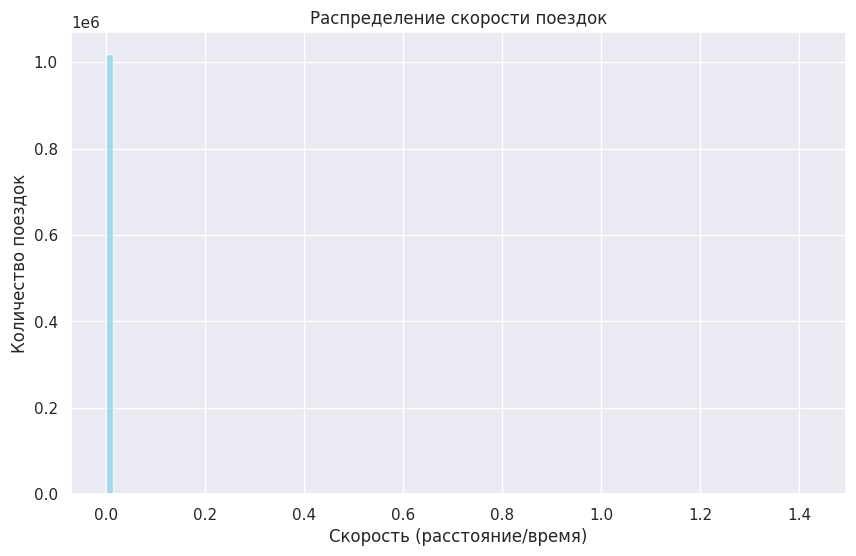

In [73]:
# Преобразуем обратно из логарифмов в секунды
train['trip_duration_seconds'] = np.expm1(train['log_trip_duration'])
test['trip_duration_seconds'] = np.expm1(test['log_trip_duration'])

# Считаем скорость
train['velocity'] = train['haversine'] / train['trip_duration_seconds']
test['velocity'] = test['haversine'] / test['trip_duration_seconds']

# Строим гистограмму
plt.figure(figsize=(10, 6))
plt.hist(train['velocity'], bins=100, alpha=0.7, color='skyblue')
plt.xlabel('Скорость (расстояние/время)')
plt.ylabel('Количество поездок')
plt.title('Распределение скорости поездок')
plt.show()

Как можно видеть по гистограмме, для некоторых объектов у нас получились очень больше значения скоростей. Нарисуйте гистограмму по объектам, для которых значение скорости получилось разумным (например, можно не включать рассмотрение объекты, где скорость больше некоторой квантили):

(array([ 41201., 145119., 161897., 155652., 138303., 110575.,  78649.,
         53749.,  36358.,  25092.]),
 array([0.        , 0.00065827, 0.00131655, 0.00197482, 0.00263309,
        0.00329136, 0.00394964, 0.00460791, 0.00526618, 0.00592446,
        0.00658273]),
 <BarContainer object of 10 artists>)

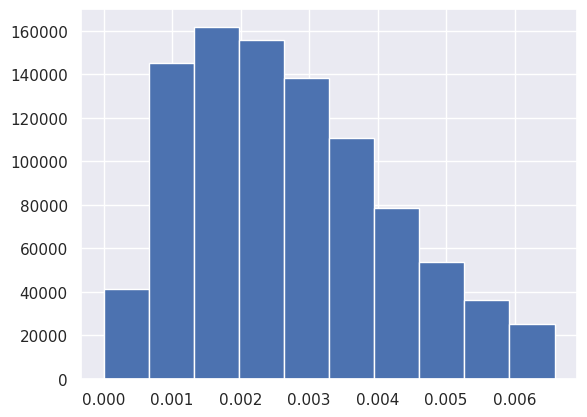

In [74]:
tmp = train[train['velocity'] < train['velocity'].mean() + train['velocity'].std()]
plt.hist(tmp['velocity'])

Для каждой пары (день недели, час суток) посчитайте медиану скоростей. Нарисуйте с помощью `sns.heatmap` график, где по осям будут дни недели и часы, а в качестве значения функции - медиана скорости

In [75]:
tmp = []

days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for day in days_of_week:
    day_data = train[train['day_of_week'] == day].groupby('hour')['velocity'].median()
    tmp.append(day_data)

# Проверяем результат
for i, day in enumerate(days_of_week):
    print(f"{day}: {len(tmp[i])} значений")

Monday: 24 значений
Tuesday: 24 значений
Wednesday: 24 значений
Thursday: 24 значений
Friday: 24 значений
Saturday: 24 значений
Sunday: 24 значений


Text(466.25, 0.5, 'day of week')

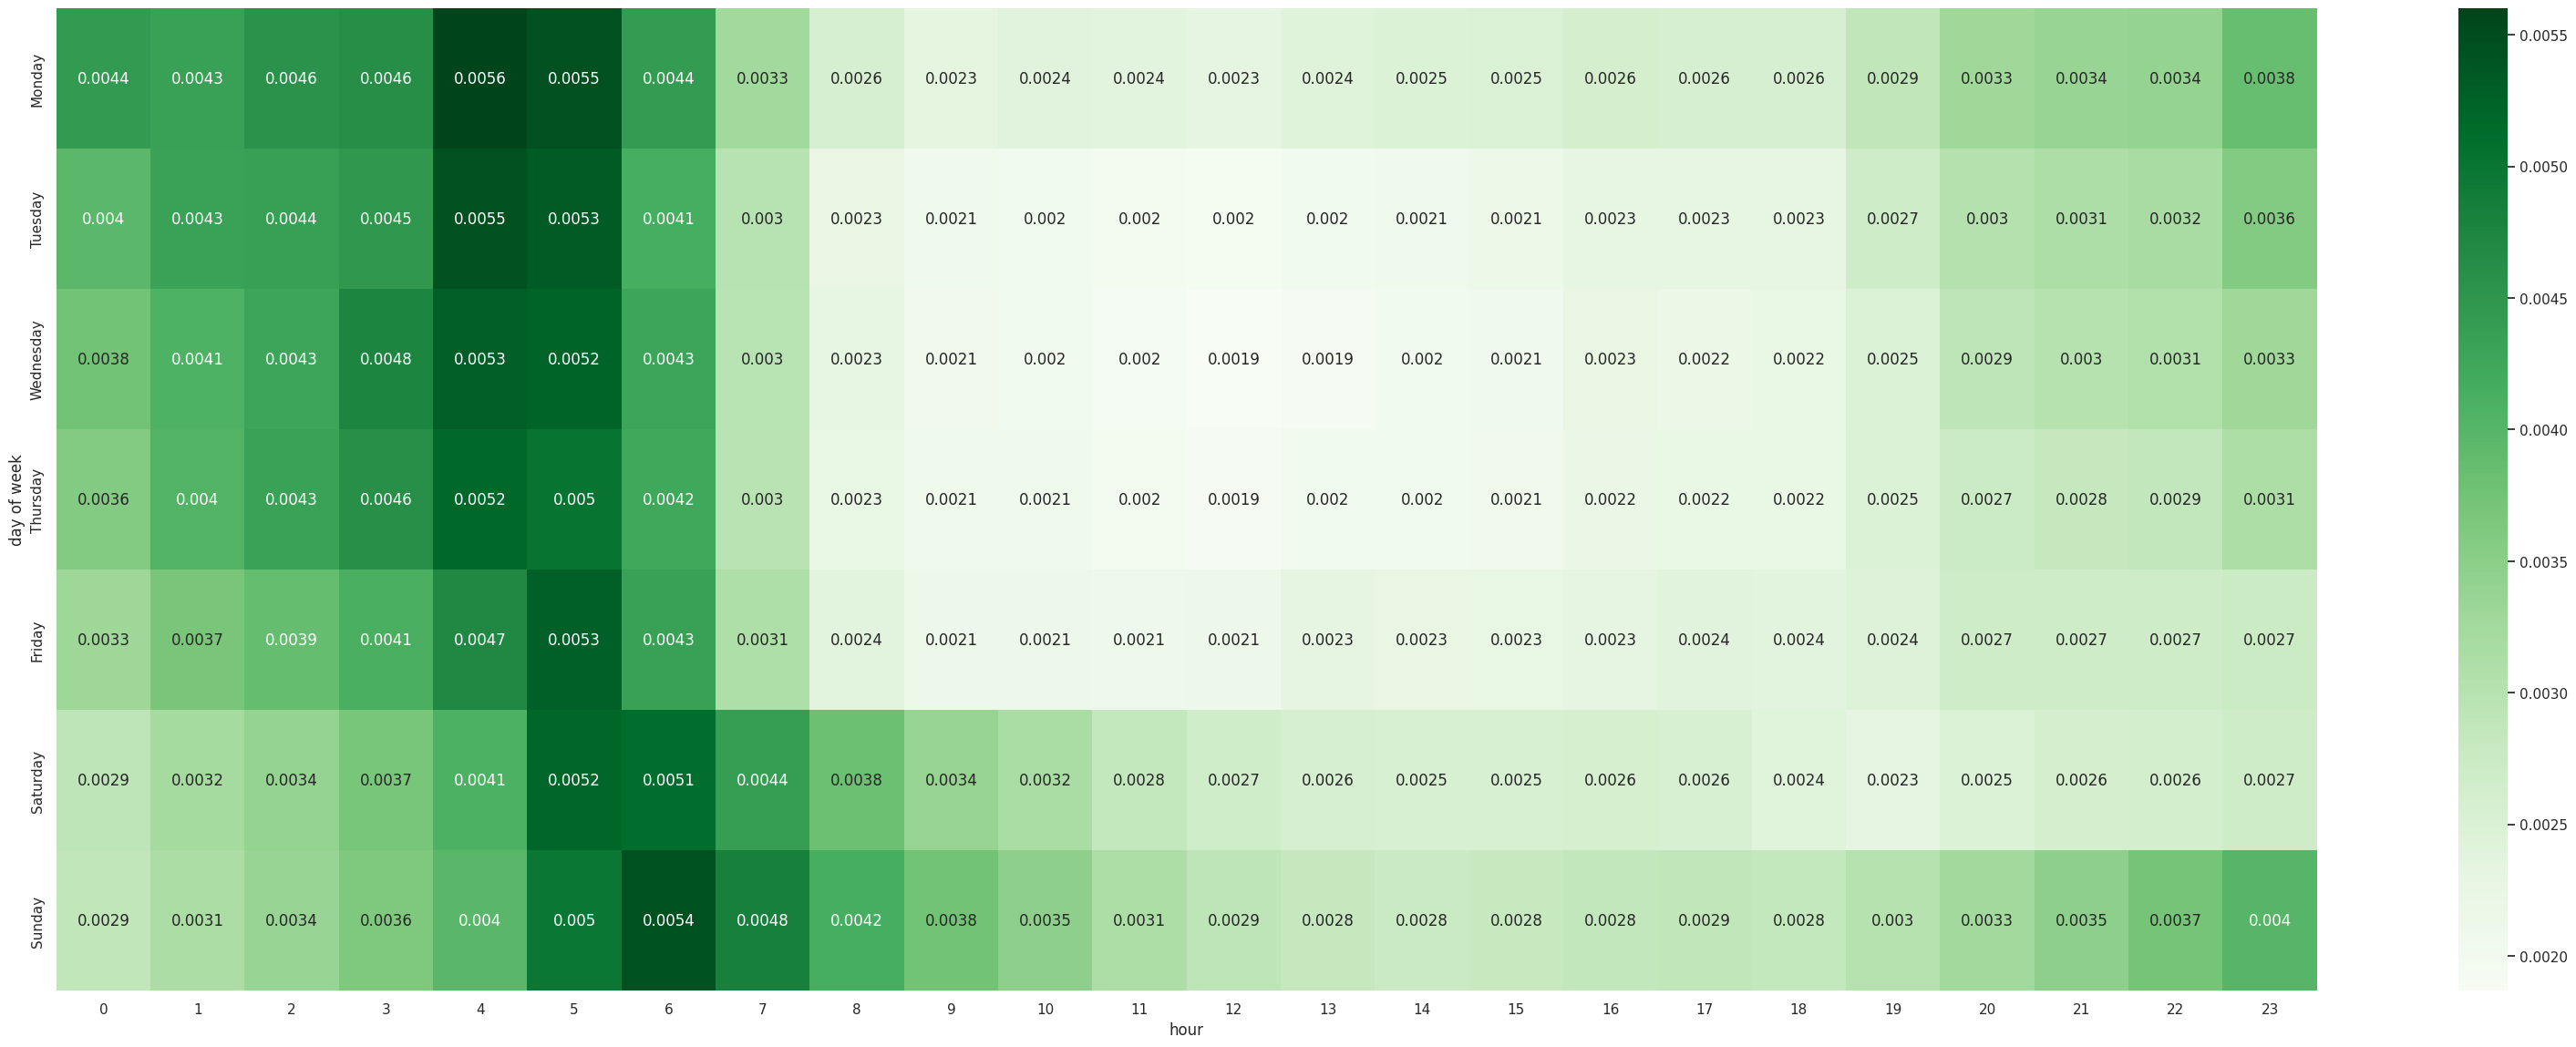

In [76]:
sns.set(rc={'figure.figsize':(40,14)})

plt.xticks(train['hour'].unique())
sns.heatmap(tmp, cmap='Greens', annot=True, yticklabels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.xlabel("hour")
plt.ylabel("day of week")

Не забудьте удалить колонку со значением скорости из данных!

**Вопрос**: Почему значение скорости нельзя использовать во время обучения?

**Ответ**: Потому что через скорость мы сразу можем получить таргет, а значит нет смысла в обучении модели, так как мы грубо говоря даем ей значение, которое надо найти. А также мы не можем для тестовой выборки понять скорость, так как у нас нет значения расстояния (которое мы и должны предсказать). Поэтому мы не можем использовать этот признак.

In [77]:
train.drop('velocity', inplace = True, axis=1)

test.drop('velocity', inplace = True, axis=1)

**Вопрос**: Посмотрите внимательно на график и скажите, в какие моменты времени скорость минимальна; максимальна.

**Ответ**: Скорость минимальна: 1) сб: с 13 до 22; 2) будние: с 8 до 19. (самые светлые на графике)

Создайте признаки "поездка совершается в период пробок" и "поездка совершается в период свободных дорог" (естественно, они не должен зависеть от скорости!):

In [78]:
train['is_slow'] = 0
train.loc[(train['hour'] > 13) & (train['hour'] < 22) & (train['day_of_week'] != 'Saturday'), 'is_slow'] = 1
train.loc[((train['hour'] > 8) & (train['hour'] < 19) & (train['day_of_week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']))), 'is_slow'] = 1

test['is_slow'] = 0
test.loc[(test['hour'] > 13) & (test['hour'] < 22) & (test['day_of_week'] != 'Saturday'), 'is_slow'] = 1
test.loc[((test['hour'] > 8) & (test['hour'] < 19) & (test['day_of_week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']))), 'is_slow'] = 1

**Задание 8 (0.25 балла)**. Для каждого из замеченных вами выше 2-3 пунктов добавьте в выборку по два признака:
- началась ли поездка в этом пункте
- закончилась ли поездка в этом пункте

Как вы думаете, почему эти признаки могут быть полезны?

In [79]:
train['airport_start'] = 0
train['airport_finish'] = 0

test['airport_start'] = 0
test['airport_finish'] = 0

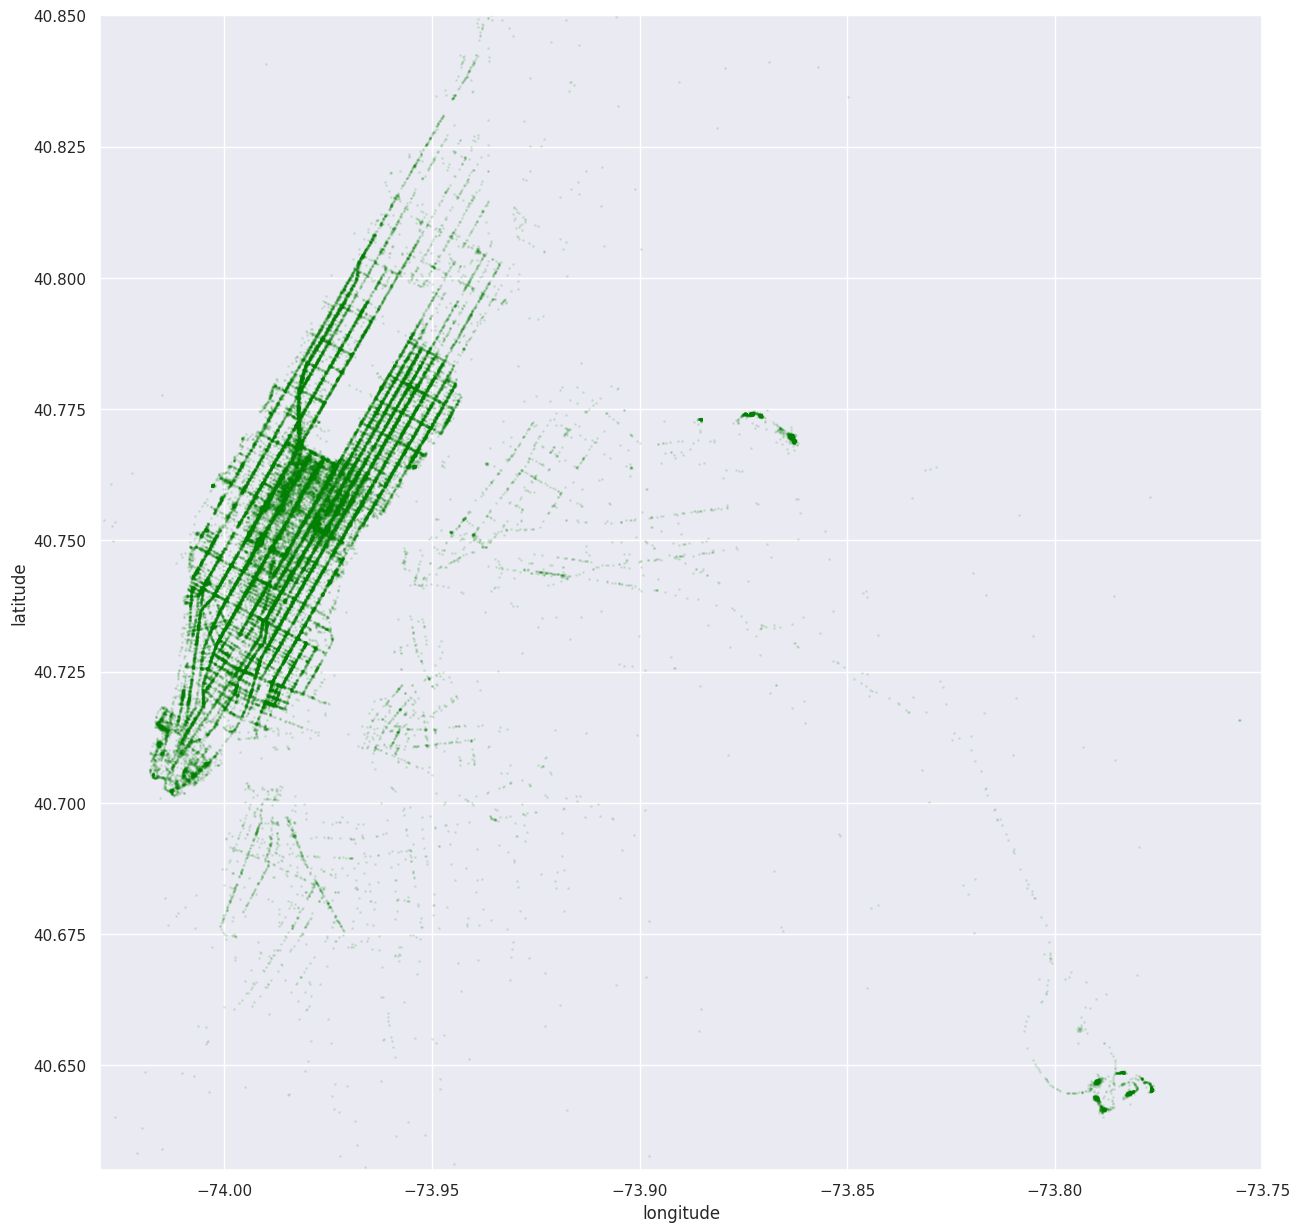

In [80]:
N = 100000
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)
plt.figure(figsize=(15,15))
plt.scatter(train['pickup_longitude'].values[:N], train['pickup_latitude'].values[:N],
              color='green', s=1, label='train', alpha=0.1)
plt.ylabel('latitude')
plt.xlabel('longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)
plt.show()

Наши две аномальные точки явно видно, и мы можем выделить границы по долготе и широте для них.


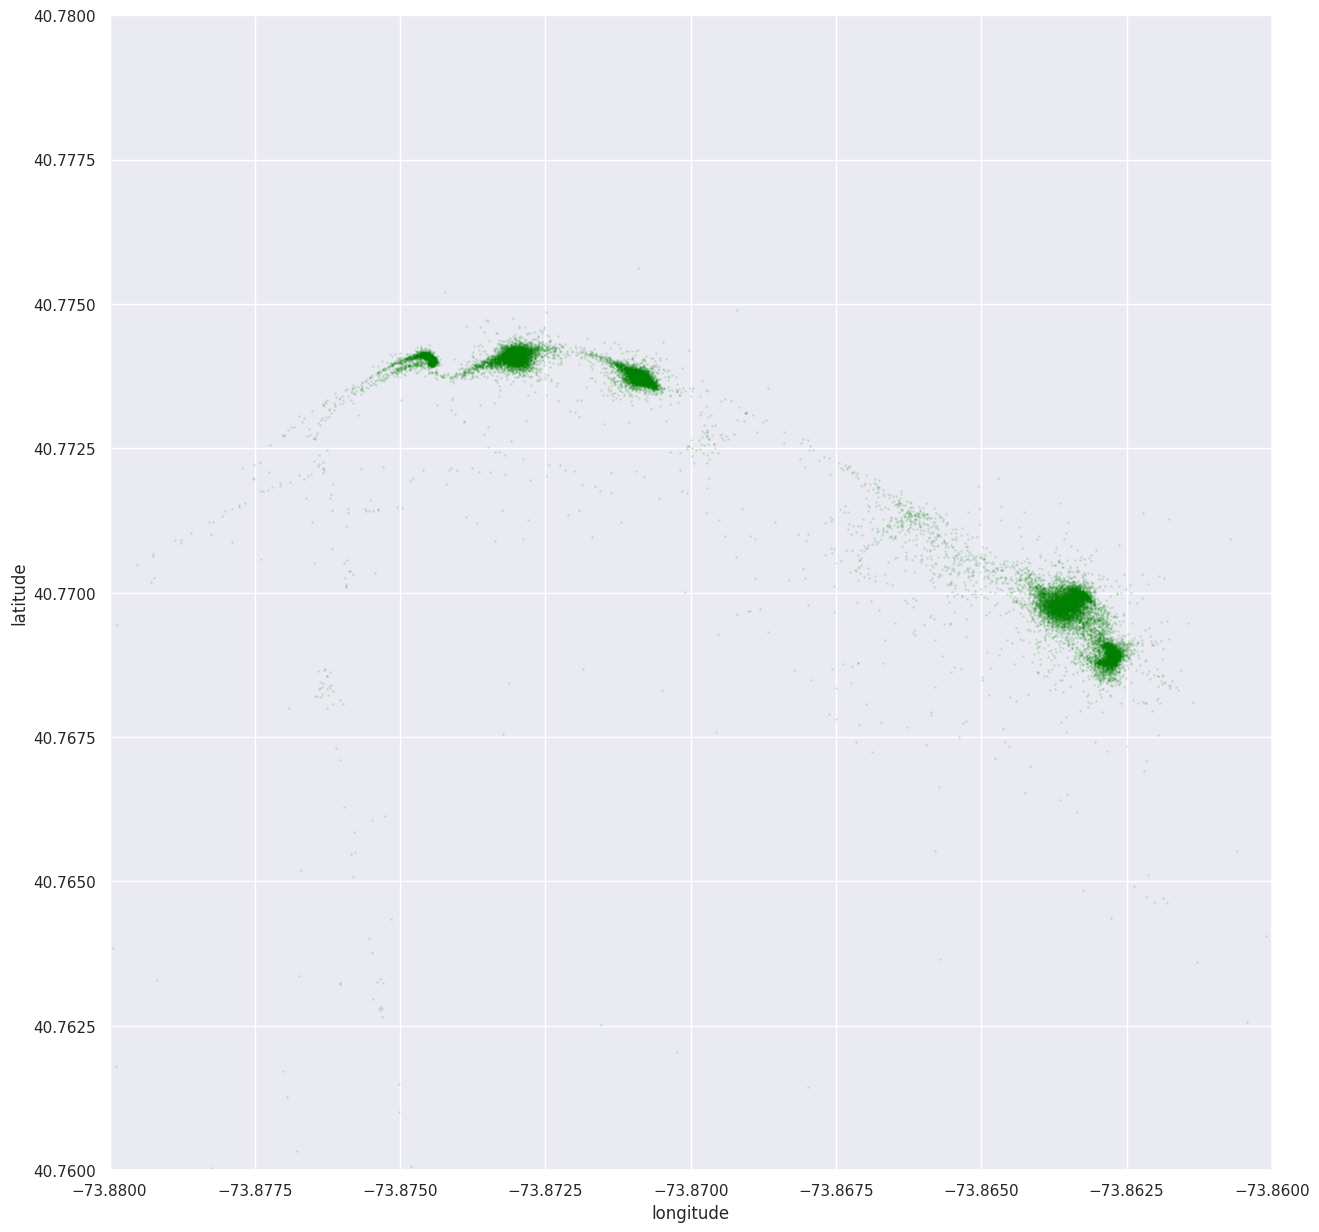

In [81]:
# 1й аэропорт (меняем только координаты для рисунка)
N = 1000000
city_long_border = (-73.88, -73.86)
city_lat_border = (40.76, 40.78)

plt.figure(figsize=(15,15))
plt.scatter(train['pickup_longitude'].values[:N], train['pickup_latitude'].values[:N],
              color='green', s=1, label='train', alpha=0.1)
plt.ylabel('latitude')
plt.xlabel('longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)
plt.show()

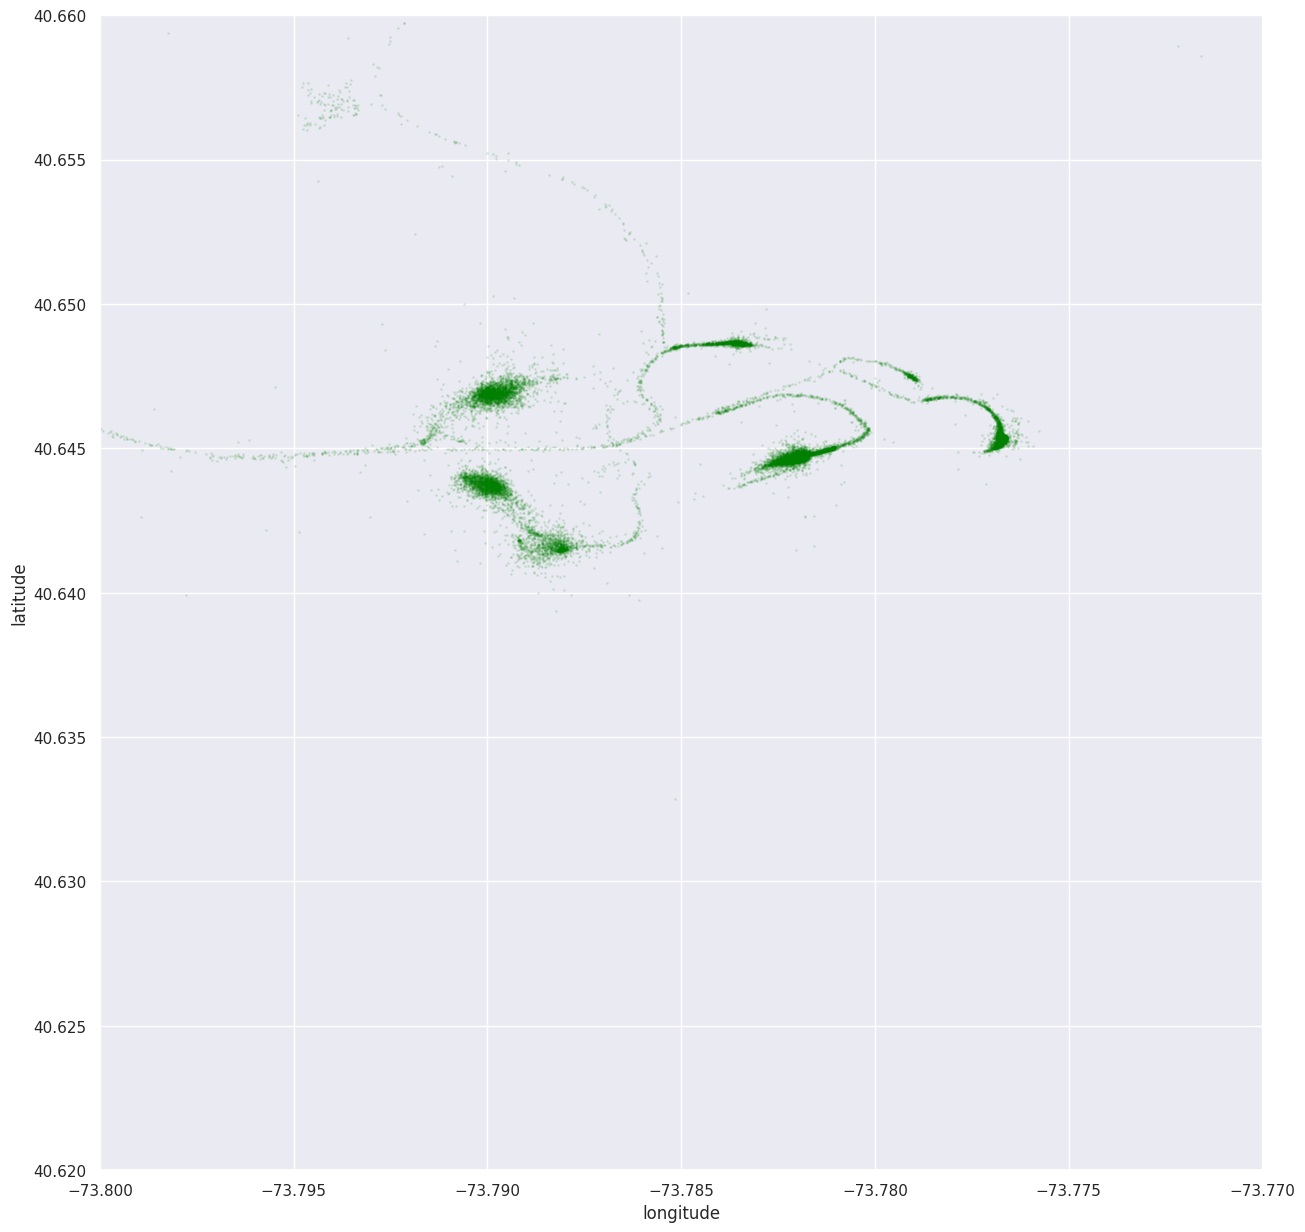

In [82]:
# 2й аэропорт
N = 1000000
city_long_border = (-73.8, -73.77)
city_lat_border = (40.62, 40.66)

plt.figure(figsize=(15,15))
plt.scatter(train['pickup_longitude'].values[:N], train['pickup_latitude'].values[:N],
              color='green', s=1, label='train', alpha=0.1)
plt.ylabel('latitude')
plt.xlabel('longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)
plt.show()

Теперь уже по координатам можем присваивать значение столбца.

In [84]:
def f1(lat,lon):
  return ((40.62 < df[lat]) & (df[lat] < 40.66) & (-73.8 < df[lon]) & (df[lon] < -73.77))

def f2(lat,lon):
  return ((40.76 < df[lat]) & (df[lat] < 40.78) & (-73.88 < df[lon]) & (df[lon] < -73.86))

In [85]:
train.loc[(f1('pickup_latitude','pickup_longitude')), 'airport_start'] = 1
train.loc[(f2('pickup_latitude','pickup_longitude')), 'airport_start'] = 2

train.loc[(f1('dropoff_latitude','dropoff_longitude')), 'airport_finish'] = 1
train.loc[(f2('dropoff_latitude','dropoff_longitude')), 'airport_finish'] = 2

test.loc[(f1('pickup_latitude','pickup_longitude')), 'airport_start'] = 1
test.loc[(f2('pickup_latitude','pickup_longitude')), 'airport_start'] = 2

test.loc[(f1('dropoff_latitude','dropoff_longitude')), 'airport_finish'] = 1
test.loc[(f2('dropoff_latitude','dropoff_longitude')), 'airport_finish'] = 2

Эта колонка будет выглядеть так:

У меня 2 колонки:
airport_start, airport_finish.


Например, для первой значения 0, 1 или 2:

0 - движение началось не в аэропорту,

1 - началось в первом аэропорту,

2 - началось во втором аэропорту.

И аналогично для airport_finish.

Для каждого из созданных признаков нарисуйте "ящик с усами" (`sns.boxplot`) распределения логарифма времени поездки

/tmp/ipython-input-318365731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airport_start', y='log_trip_duration', palette="Set3", data=train)


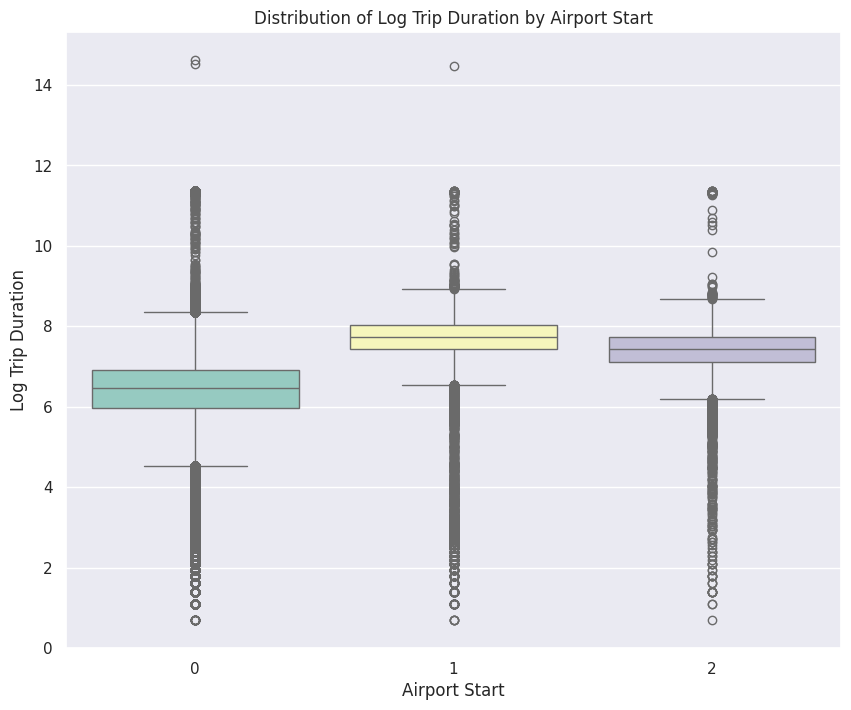

In [93]:
plt.rcParams['figure.figsize'] = 10, 8
sns.boxplot(x='airport_start', y='log_trip_duration', palette="Set3", data=train)
plt.title('Distribution of Log Trip Duration by Airport Start')
plt.xlabel('Airport Start')
plt.ylabel('Log Trip Duration')
plt.show()

/tmp/ipython-input-2381586984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airport_finish', y='log_trip_duration', palette="Set3", data=train)


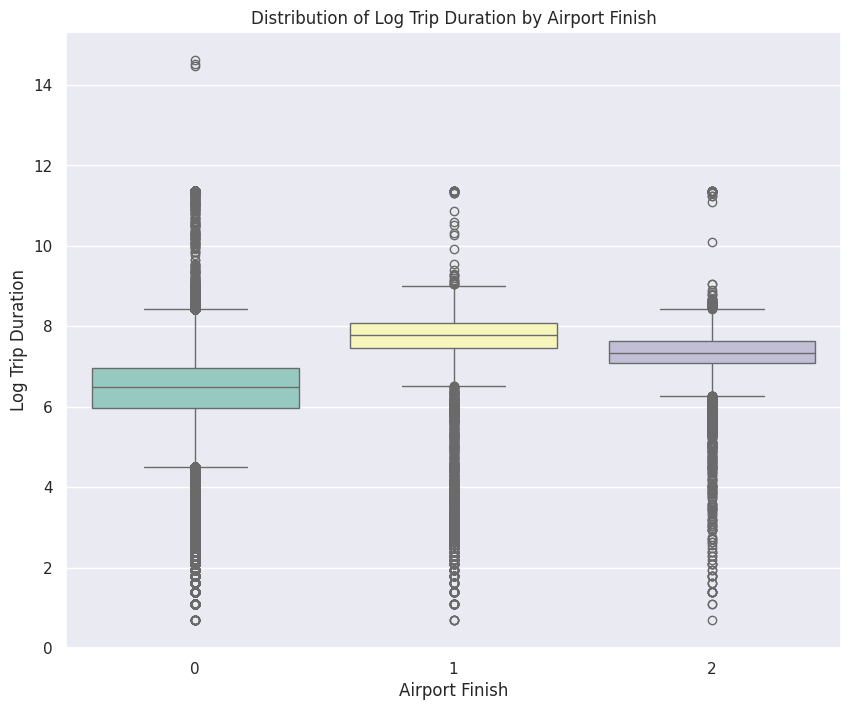

In [94]:
plt.rcParams['figure.figsize'] = 10, 8
sns.boxplot(x='airport_finish', y='log_trip_duration', palette="Set3", data=train)
plt.title('Distribution of Log Trip Duration by Airport Finish')
plt.xlabel('Airport Finish')
plt.ylabel('Log Trip Duration')
plt.show()

**Вопрос**: судя по графикам, как вы думаете, хорошими ли получились эти признаки?

**Ответ:** Длительность поездок, которые начинаются или заканчиваются в аэропортах, больше, чем у других. Это логично, поэтому будем считать признаки хорошими.

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Задание 9 (1 балл)**. Сейчас мы почти что не используем сами значения координат. На это есть несколько причин: по отдельности рассматривать широту и долготу не имеет особого смысла, стоит рассматривать их вместе. Во-вторых, понятно, что зависимость между нашим таргетом и координатами не линейная. Чтобы как-то использовать координаты, можно прибегнуть к следующему трюку: обрамим область с наибольшим количеством поездок прямоугольником (как на рисунке). Разобьем этот прямоугольник на ячейки. Каждой точке сопоставим номер ее ячейки, а тем точкам, что не попали ни в одну из ячеек, сопоставим значение -1.

Напишите трансформер, который сначала разбивает показанную на рисунке область на ячейки, а затем создает два признака: номер ячейки, в которой началась поездка, и номер ячейки, в которой закончилась поездка. Количество строк и столбцов выберите самостоятельно.

Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики (если они вдруг нужны) нужно считать только по обучающей выборке в методе `fit`:

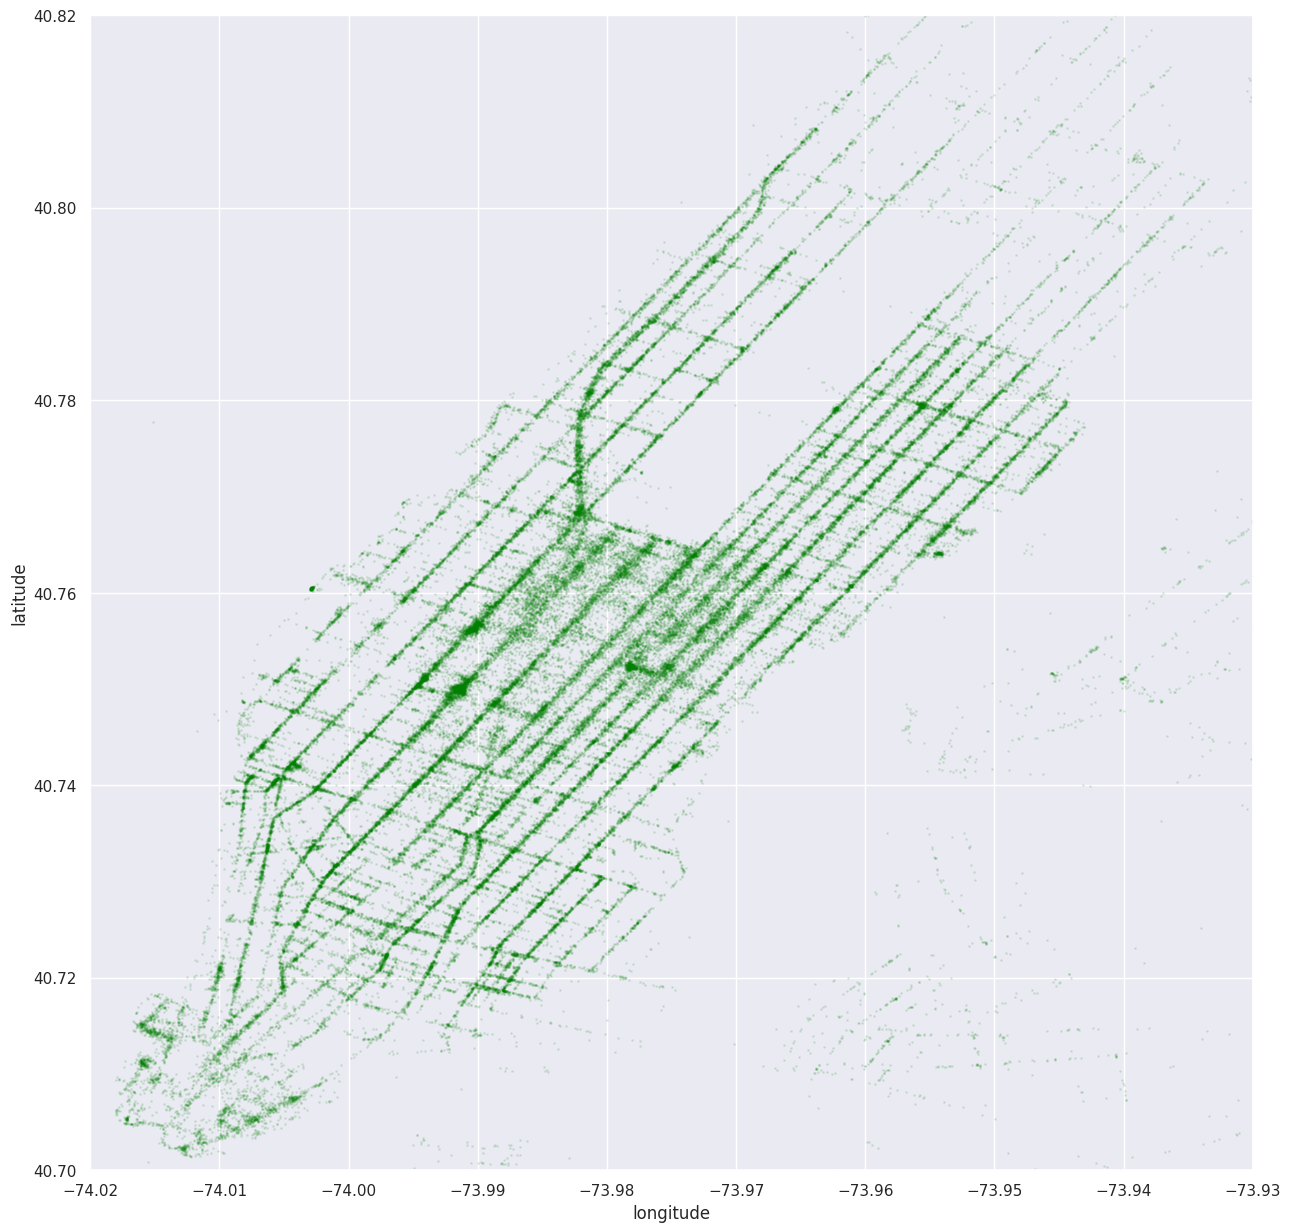

In [95]:
# часть карты, где много поездок
N = 100000
city_long_border = (-74.02, -73.93)
city_lat_border = (40.70, 40.82)
plt.figure(figsize=(15,15))
plt.scatter(train['pickup_longitude'].values[:N], train['pickup_latitude'].values[:N],
              color='green', s=1, label='train', alpha=0.1)
plt.ylabel('latitude')
plt.xlabel('longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)
plt.show()

In [96]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder

# TransformerMixin implements fit_transform for you,
# applying your fit and transform consistently

class MapGridTransformer(BaseEstimator, TransformerMixin):
    #def __init__(self, ...):
    #    pass

    def show_map(self, X=None):
        map = show_circles_on_map(train.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

        line_1 = [(40.82, -74.02), (40.82, -73.93)]
        folium.PolyLine(line_1, color = 'red', weight=5).add_to(map)

        line_2 = [(40.79, -74.02), (40.79, -73.93)]
        folium.PolyLine(line_2, color = 'red', weight=5).add_to(map)

        line_3 = [(40.76, -74.02), (40.76, -73.93)]
        folium.PolyLine(line_3, color = 'red', weight=5).add_to(map)

        line_4 = [(40.73, -74.02), (40.73, -73.93)]
        folium.PolyLine(line_4, color = 'red', weight=5).add_to(map)

        line_5 = [(40.70, -74.02), (40.70, -73.93)]
        folium.PolyLine(line_5, color = 'red', weight=5).add_to(map)

        line_6 = [(40.82, -74.02), (40.70, -74.02)]
        folium.PolyLine(line_6, color = 'red', weight=5).add_to(map)

        line_7 = [(40.82, -73.99), (40.70, -73.99)]
        folium.PolyLine(line_7, color = 'red', weight=5).add_to(map)

        line_8 = [(40.82, -73.96), (40.70, -73.96)]
        folium.PolyLine(line_8, color = 'red', weight=5).add_to(map)

        line_9 = [(40.82, -73.93), (40.70, -73.93)]
        folium.PolyLine(line_9, color = 'red', weight=5).add_to(map)

        return map

    def fit(self, X=None, y=None):
        # your code here
        self.X = X.copy()

        self.X['grid_first'] = -1
        self.X['grid_second'] = -1

        # да, это выглядит страшно, но я разбила на квадратики руками (12 квадратиков)

        self.mask_of_square1_f = [((self.X['pickup_latitude'] > 40.79) & (self.X['pickup_latitude'] < 40.82) & (self.X['pickup_longitude'] > -74.02) & (self.X['pickup_longitude'] <= -73.99))]
        self.mask_of_square1_s = [((self.X['dropoff_latitude'] > 40.79) & (self.X['dropoff_latitude'] < 40.82) & (self.X['dropoff_longitude'] > -74.02) & (self.X['dropoff_longitude'] <= -73.99))]

        self.mask_of_square2_f = [((self.X['pickup_latitude'] > 40.79) & (self.X['pickup_latitude'] < 40.82) & (self.X['pickup_longitude'] > -73.99) & (self.X['pickup_longitude'] <= -73.96))]
        self.mask_of_square2_s = [((self.X['dropoff_latitude'] > 40.79) & (self.X['dropoff_latitude'] < 40.82) & (self.X['dropoff_longitude'] > -73.99) & (self.X['dropoff_longitude'] <= -73.96))]

        self.mask_of_square3_f = [((self.X['pickup_latitude'] > 40.79) & (self.X['pickup_latitude'] < 40.82) & (self.X['pickup_longitude'] > -73.96) & (self.X['pickup_longitude'] <= -73.93))]
        self.mask_of_square3_s = [((self.X['dropoff_latitude'] > 40.79) & (self.X['dropoff_latitude'] < 40.82) & (self.X['dropoff_longitude'] > -73.96) & (self.X['dropoff_longitude'] <= -73.93))]

        self.mask_of_square4_f = [((self.X['pickup_latitude'] > 40.76) & (self.X['pickup_latitude'] <= 40.79) & (self.X['pickup_longitude'] > -74.02) & (self.X['pickup_longitude'] <= -73.99))]
        self.mask_of_square4_s = [((self.X['dropoff_latitude'] > 40.76) & (self.X['dropoff_latitude'] <= 40.79) & (self.X['dropoff_longitude'] > -74.02) & (self.X['dropoff_longitude'] <= -73.99))]

        self.mask_of_square5_f = [((self.X['pickup_latitude'] > 40.76) & (self.X['pickup_latitude'] <= 40.79) & (self.X['pickup_longitude'] > -73.99) & (self.X['pickup_longitude'] <= -73.96))]
        self.mask_of_square5_s = [((self.X['dropoff_latitude'] > 40.76) & (self.X['dropoff_latitude'] <= 40.79) & (self.X['dropoff_longitude'] > -73.99) & (self.X['dropoff_longitude'] <= -73.96))]

        self.mask_of_square6_f = [((self.X['pickup_latitude'] > 40.76) & (self.X['pickup_latitude'] <= 40.79) & (self.X['pickup_longitude'] > -73.96) & (self.X['pickup_longitude'] <= -73.93))]
        self.mask_of_square6_s = [((self.X['dropoff_latitude'] > 40.76) & (self.X['dropoff_latitude'] <= 40.79) & (self.X['dropoff_longitude'] > -73.96) & (self.X['dropoff_longitude'] <= -73.93))]

        self.mask_of_square7_f = [((self.X['pickup_latitude'] > 40.73) & (self.X['pickup_latitude'] <= 40.76) & (self.X['pickup_longitude'] > -74.02) & (self.X['pickup_longitude'] <= -73.99))]
        self.mask_of_square7_s = [((self.X['dropoff_latitude'] > 40.73) & (self.X['dropoff_latitude'] <= 40.76) & (self.X['dropoff_longitude'] > -74.02) & (self.X['dropoff_longitude'] <= -73.99))]

        self.mask_of_square8_f = [((self.X['pickup_latitude'] > 40.73) & (self.X['pickup_latitude'] <= 40.76) & (self.X['pickup_longitude'] > -73.99) & (self.X['pickup_longitude'] <= -73.96))]
        self.mask_of_square8_s = [((self.X['dropoff_latitude'] > 40.73) & (self.X['dropoff_latitude'] <= 40.76) & (self.X['dropoff_longitude'] > -73.99) & (self.X['dropoff_longitude'] <= -73.96))]

        self.mask_of_square9_f = [((self.X['pickup_latitude'] > 40.73) & (self.X['pickup_latitude'] <= 40.76) & (self.X['pickup_longitude'] > -73.96) & (self.X['pickup_longitude'] <= -73.93))]
        self.mask_of_square9_s = [((self.X['dropoff_latitude'] > 40.73) & (self.X['dropoff_latitude'] <= 40.76) & (self.X['dropoff_longitude'] > -73.96) & (self.X['dropoff_longitude'] <= -73.93))]

        self.mask_of_square10_f = [((self.X['pickup_latitude'] > 40.70) & (self.X['pickup_latitude'] <= 40.73) & (self.X['pickup_longitude'] > -74.02) & (self.X['pickup_longitude'] <= -73.99))]
        self.mask_of_square10_s = [((self.X['dropoff_latitude'] > 40.70) & (self.X['dropoff_latitude'] <= 40.73) & (self.X['dropoff_longitude'] > -74.02) & (self.X['dropoff_longitude'] <= -73.99))]

        self.mask_of_square11_f = [((self.X['pickup_latitude'] > 40.70) & (self.X['pickup_latitude'] <= 40.73) & (self.X['pickup_longitude'] > -73.99) & (self.X['pickup_longitude'] <= -73.96))]
        self.mask_of_square11_s = [((self.X['dropoff_latitude'] > 40.70) & (self.X['dropoff_latitude'] <= 40.73) & (self.X['dropoff_longitude'] > -73.99) & (self.X['dropoff_longitude'] <= -73.96))]

        self.mask_of_square12_f = [((self.X['pickup_latitude'] > 40.70) & (self.X['pickup_latitude'] <= 40.73) & (self.X['pickup_longitude'] > -73.96) & (self.X['pickup_longitude'] <= -73.93))]
        self.mask_of_square12_s = [((self.X['dropoff_latitude'] > 40.70) & (self.X['dropoff_latitude'] <= 40.73) & (self.X['dropoff_longitude'] > -73.96) & (self.X['dropoff_longitude'] <= -73.93))]

        return self

    def transform(self, X, y=None):
        # your code here
        tmp = self.X[self.mask_of_square1_f[0]].copy()
        self.X.loc[self.mask_of_square1_f[0], ['grid_first']] = 1
        tmp = self.X[self.mask_of_square1_s[0]].copy()
        self.X.loc[self.mask_of_square1_s[0], ['grid_second']] = 1

        tmp = self.X[self.mask_of_square2_f[0]].copy()
        self.X.loc[self.mask_of_square2_f[0], ['grid_first']] = 2
        tmp = self.X[self.mask_of_square2_s[0]].copy()
        self.X.loc[self.mask_of_square2_s[0], ['grid_second']] = 2

        tmp = self.X[self.mask_of_square3_f[0]].copy()
        self.X.loc[self.mask_of_square3_f[0], ['grid_first']] = 3
        tmp = self.X[self.mask_of_square3_s[0]].copy()
        self.X.loc[self.mask_of_square3_s[0], ['grid_second']] = 3

        tmp = self.X[self.mask_of_square4_f[0]].copy()
        self.X.loc[self.mask_of_square4_f[0], ['grid_first']] = 4
        tmp = self.X[self.mask_of_square4_s[0]].copy()
        self.X.loc[self.mask_of_square4_s[0], ['grid_second']] = 4

        tmp = self.X[self.mask_of_square5_f[0]].copy()
        self.X.loc[self.mask_of_square5_f[0], ['grid_first']] = 5
        tmp = self.X[self.mask_of_square5_s[0]].copy()
        self.X.loc[self.mask_of_square5_s[0], ['grid_second']] = 5

        tmp = self.X[self.mask_of_square6_f[0]].copy()
        self.X.loc[self.mask_of_square6_f[0], ['grid_first']] = 6
        tmp = self.X[self.mask_of_square6_s[0]].copy()
        self.X.loc[self.mask_of_square6_s[0], ['grid_second']] = 6

        tmp = self.X[self.mask_of_square7_f[0]].copy()
        self.X.loc[self.mask_of_square7_f[0], ['grid_first']] = 7
        tmp = self.X[self.mask_of_square7_s[0]].copy()
        self.X.loc[self.mask_of_square7_s[0], ['grid_second']] = 7

        tmp = self.X[self.mask_of_square8_f[0]].copy()
        self.X.loc[self.mask_of_square8_f[0], ['grid_first']] = 8
        tmp = self.X[self.mask_of_square8_s[0]].copy()
        self.X.loc[self.mask_of_square8_s[0], ['grid_second']] = 8

        tmp = self.X[self.mask_of_square9_f[0]].copy()
        self.X.loc[self.mask_of_square9_f[0], ['grid_first']] = 9
        tmp = self.X[self.mask_of_square9_s[0]].copy()
        self.X.loc[self.mask_of_square9_s[0], ['grid_second']] = 9

        tmp = self.X[self.mask_of_square9_f[0]].copy()
        self.X.loc[self.mask_of_square9_f[0], ['grid_first']] = 10
        tmp = self.X[self.mask_of_square9_s[0]].copy()
        self.X.loc[self.mask_of_square9_s[0], ['grid_second']] = 10

        tmp = self.X[self.mask_of_square11_f[0]].copy()
        self.X.loc[self.mask_of_square11_f[0], ['grid_first']] = 11
        tmp = self.X[self.mask_of_square11_s[0]].copy()
        self.X.loc[self.mask_of_square11_s[0], ['grid_second']] = 11

        tmp = self.X[self.mask_of_square12_f[0]].copy()
        self.X.loc[self.mask_of_square12_f[0], ['grid_first']] = 12
        tmp = self.X[self.mask_of_square12_s[0]].copy()
        self.X.loc[self.mask_of_square12_s[0], ['grid_second']] = 12

        return self.X

In [97]:
grid1 = MapGridTransformer()
grid1.fit(train)
add_train = grid1.transform(train)

grid2 = MapGridTransformer()
grid2.fit(test)
add_test = grid2.transform(test)

In [98]:
grid1.show_map()

In [99]:
train['grid_first'] = add_train['grid_first']
train['grid_second'] = add_train['grid_second']

test['grid_first'] = add_test['grid_first']
test['grid_second'] = add_test['grid_second']

**Задание 10 (0.25 балла)**. Обучите `Ridge`-регрессию со стандартными параметрами на признаках, которые мы выделили к текущему моменту. Категориальные признаки закодируйте через one-hot-кодирование, числовые признаки отмасштабируйте.

In [100]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week', 'month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week', 'month', 'is_bad', 'log_haversine',  'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [102]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

notnum_feats = ['hour', 'day_of_week', 'month', 'airport_start', 'airport_finish', 'grid_first', 'grid_second']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Используем root_mean_squared_error для RMSE
print("Test RMSE = %.4f" % root_mean_squared_error(y_test, y_pred))
print("Test MSE = %.4f" % mean_squared_error(y_test, y_pred))

y_train_pred = model.predict(X_train)
print("Train RMSE = %.4f" % root_mean_squared_error(y_train, y_train_pred))
print("Train MSE = %.4f" % mean_squared_error(y_train, y_train_pred))

Test RMSE = 0.5459
Test MSE = 0.2980
Train RMSE = 0.5498
Train MSE = 0.3022


## Часть 3. Изучаем оставшиеся признаки (1 балл)

**Задание 11 (0.75 баллов)**. У нас осталось еще 3 признака, которые мы не исследовали: `vendor_id`, `passenger_count` и `store_and_fwd_flag`.

**Вопрос**: Подумайте, почему каждый из этих признаков может быть потенциально полезным.

Посчитайте, сколько есть уникальных значений у каждого из этих признаков:

In [103]:
print('count of unique values:')
print('vendor_id:', train['vendor_id'].unique().shape[0])
print('passenger_count:', train['passenger_count'].unique().shape[0])
print('store_and_fwd_flag:', train['store_and_fwd_flag'].unique().shape[0])

count of unique values:
vendor_id: 2
passenger_count: 10
store_and_fwd_flag: 2


Постройте "ящики с усами" распределений логарифма времени поездки в зависимости от значений каждого из признаков

/tmp/ipython-input-3095125341.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = train['log_trip_duration'], palette="Set3", data = train, x = train['vendor_id'])


<Axes: xlabel='vendor_id', ylabel='log_trip_duration'>

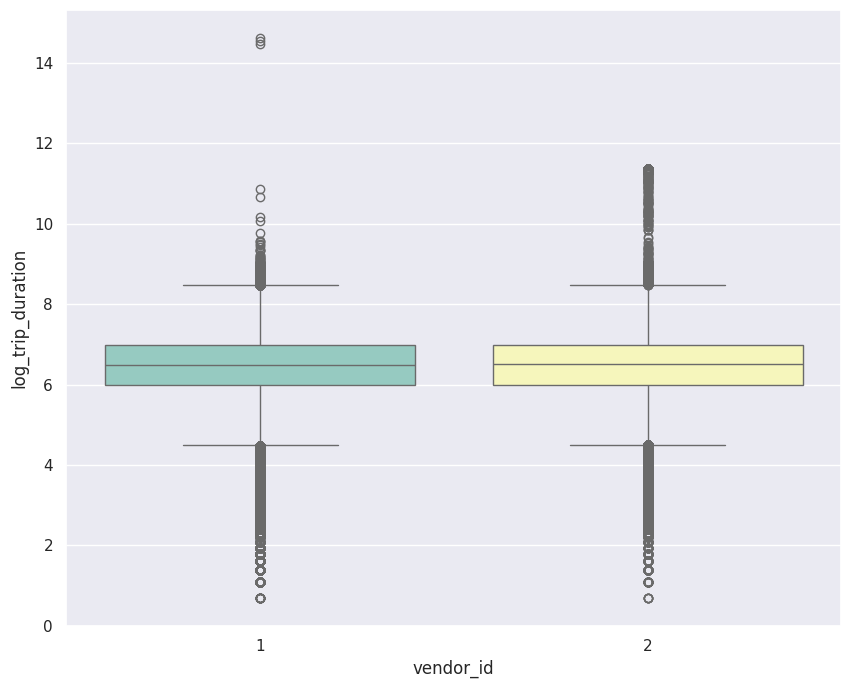

In [104]:
sns.boxplot(y = train['log_trip_duration'], palette="Set3", data = train, x = train['vendor_id'])

/tmp/ipython-input-107814194.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = train['log_trip_duration'], palette="Set3", data = train, x = train['passenger_count'])


<Axes: xlabel='passenger_count', ylabel='log_trip_duration'>

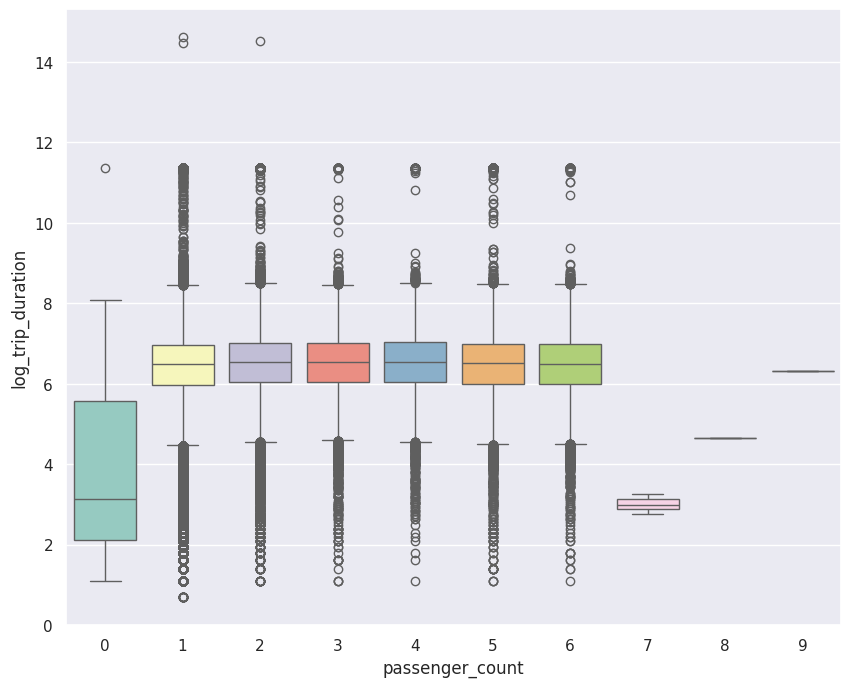

In [105]:
sns.boxplot(y = train['log_trip_duration'], palette="Set3", data = train, x = train['passenger_count'])

/tmp/ipython-input-1502347089.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = train['log_trip_duration'], palette="Set3", data = train, x = train['store_and_fwd_flag'])


<Axes: xlabel='store_and_fwd_flag', ylabel='log_trip_duration'>

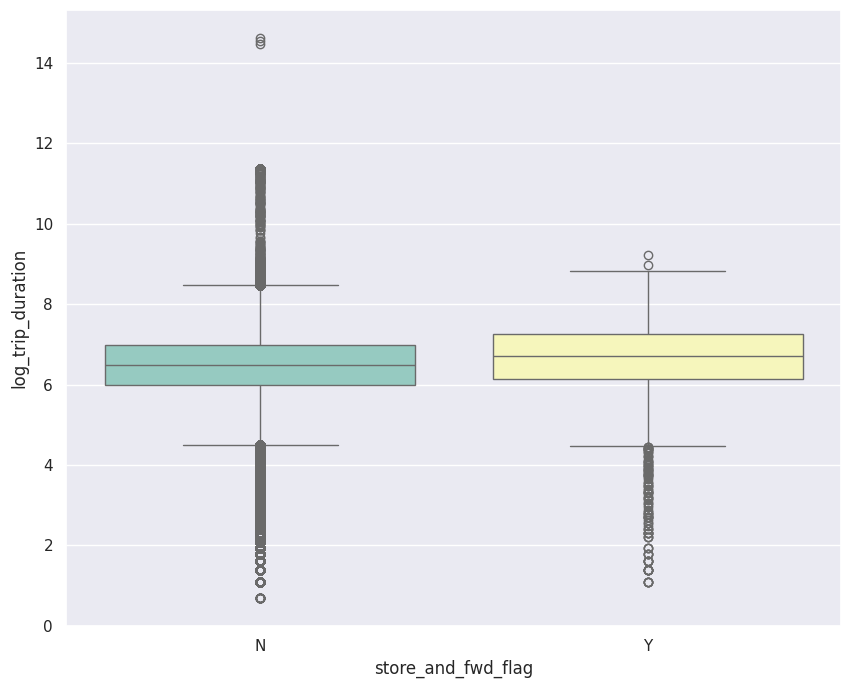

In [106]:
sns.boxplot(y = train['log_trip_duration'], palette="Set3", data = train, x = train['store_and_fwd_flag'])

Переведите признаки `vendor_id` и `store_and_fwd_flag` в значения $\{0;1\}$

In [107]:
train['vendor_id'] = train['vendor_id'].replace({1 : 0, 2 : 1})
train['store_and_fwd_flag'] = train['store_and_fwd_flag'].replace({'N' : 0, 'Y' : 1})

test['vendor_id'] = test['vendor_id'].replace({1 : 0, 2 : 1})
test['store_and_fwd_flag'] = test['store_and_fwd_flag'].replace({'N' : 0, 'Y' : 1})

/tmp/ipython-input-2068975390.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['store_and_fwd_flag'] = train['store_and_fwd_flag'].replace({'N' : 0, 'Y' : 1})
/tmp/ipython-input-2068975390.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test['store_and_fwd_flag'] = test['store_and_fwd_flag'].replace({'N' : 0, 'Y' : 1})


**Вопрос**: Основываясь на графиках выше, как вы думаете, будут ли эти признаки сильными?

Ответ: Кажется, что эти признаки нам не помогут, потому что для разных значений признака мы получаем практически одинаковые значения целевой переменной. Только если passenger_count: когда этот признак равен 0, то продолжительность меньше, так как это скорее всего те случаи, когда такси едет к заказчику, а в данном случае обычно выбирается одна из ближайших машин => продолжительность меньше; когда != 0, то продолжительность больше. Также при store_and_fwd_flag == 'Y' продолжительность немного больше, но это не значительно. Попробуем дальше предположить, что эти признаки как-то влияют, и посмотрим, как будет работать модель. Но такие признаки мне кажутся немного бесполезными.

**Задание 12 (0.25 баллов)**. Проверьте свои предположения, обучив модель в том числе и на этих трех признаках. Обучайте `Ridge`-регрессию со стандартными параметрами. Категориальные признаки закодируйте one-hot-кодированием, а численные отмасштабируйте.

In [108]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week', 'month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second', 'vendor_id', 'store_and_fwd_flag', 'passenger_count']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week', 'month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second', 'vendor_id', 'store_and_fwd_flag', 'passenger_count']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [110]:
from sklearn.metrics import mean_squared_error
import numpy as np

notnum_feats = ['hour', 'day_of_week', 'month', 'airport_start', 'airport_finish', 'grid_first', 'vendor_id', 'grid_second', 'store_and_fwd_flag']
num_feats = ['day_of_year', 'passenger_count', 'is_bad', 'is_slow', 'log_haversine']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Вычисляем RMSE через квадратный корень из MSE
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5457
Test MSE = 0.2978
Train RMSE = 0.5495
Train MSE = 0.3020


**Ответ:** Особого улучшения модели нет, поэтому не стоит учитывать эти признаки.

Если признаки не дали какого-то ощутимого улучшения метрики, их можно выбросить из данных.

## Часть 4. Улучшаем модель (3 балла)

**Задание 13 (1 балл)**. В наших данных есть нетипичные объекты: с аномально маленьким времени поездки, с очень большим пройденным расстоянием или очень большими остатками регрессии. В этом задании предлагается исключить такие объекты из обучающей выборки. Для этого нарисуйте гистограммы распределения упомянутых выше величин, выберите объекты, которые можно назвать выбросами, и очистите обучающую выборку от них.

Отметим, что хотя эти объекты и выглядят как выбросы, в тестовой выборке тоже скорее всего будут объекты с такими же странными значениями целевой переменной и/или признаков. Поэтому, возможно, чистка обучающей выборки приведёт к ухудшению качества на тесте. Тем не менее, всё равно лучше удалять выбросы из обучения, чтобы модель получалась более разумной и интерпретируемой.

In [115]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [117]:
from sklearn.metrics import mean_squared_error
import numpy as np

notnum_feats = ['hour', 'day_of_week', 'month', 'airport_start', 'airport_finish', 'grid_first', 'grid_second']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ RMSE ПРАВИЛЬНО - БЕЗ ПАРАМЕТРА squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5459
Test MSE = 0.2980
Train RMSE = 0.5498
Train MSE = 0.3022


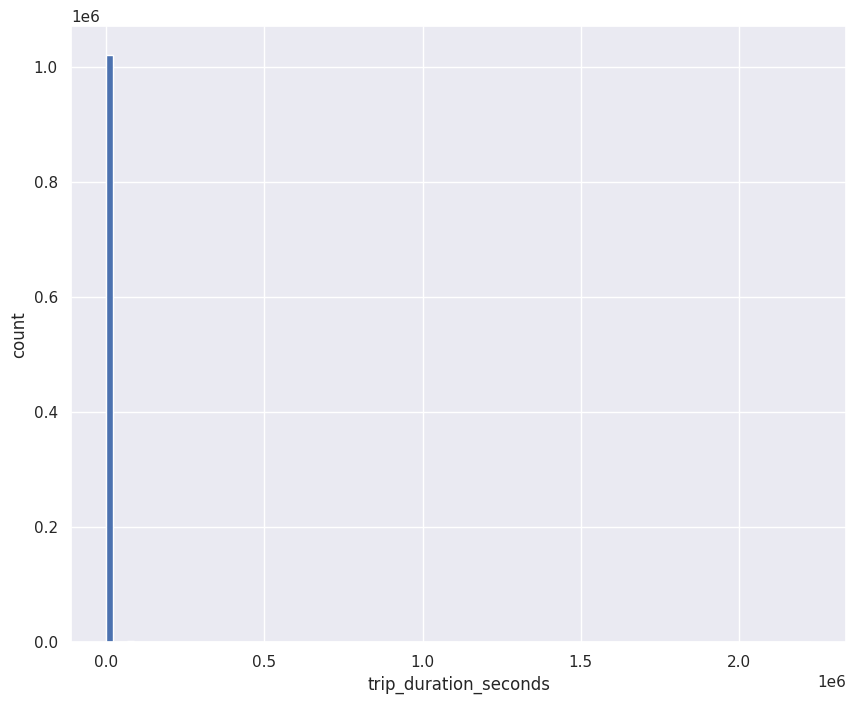

In [120]:
plt.hist(train['trip_duration_seconds'], bins=100)
plt.xlabel('trip_duration_seconds')
plt.ylabel('count')
plt.show()

In [122]:
train = train[(train['trip_duration_seconds'] < train['trip_duration_seconds'].quantile(0.90))]

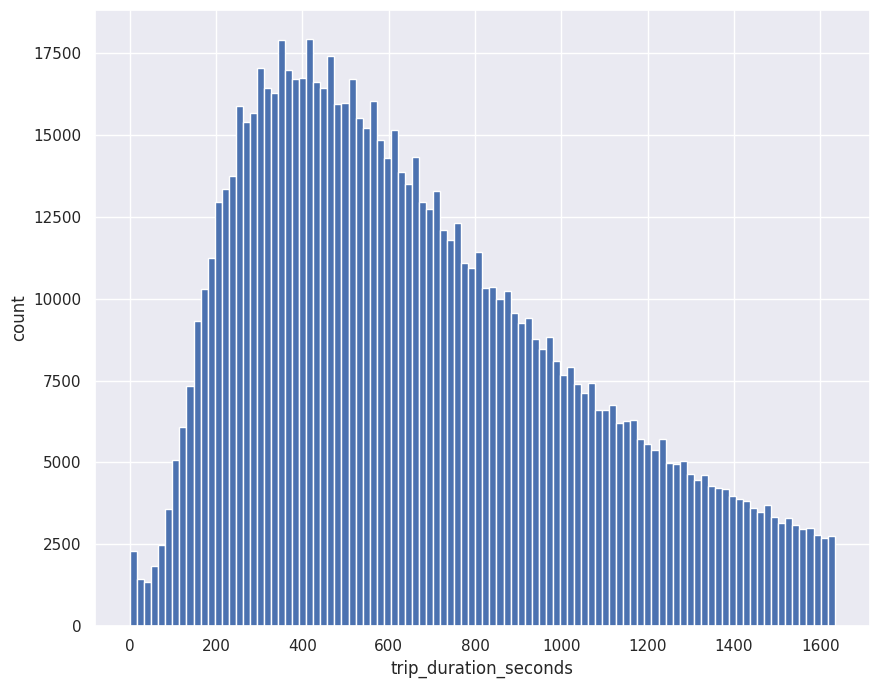

In [123]:
plt.hist(train['trip_duration_seconds'], bins=100)
plt.xlabel('trip_duration_seconds')
plt.ylabel('count')
plt.show()

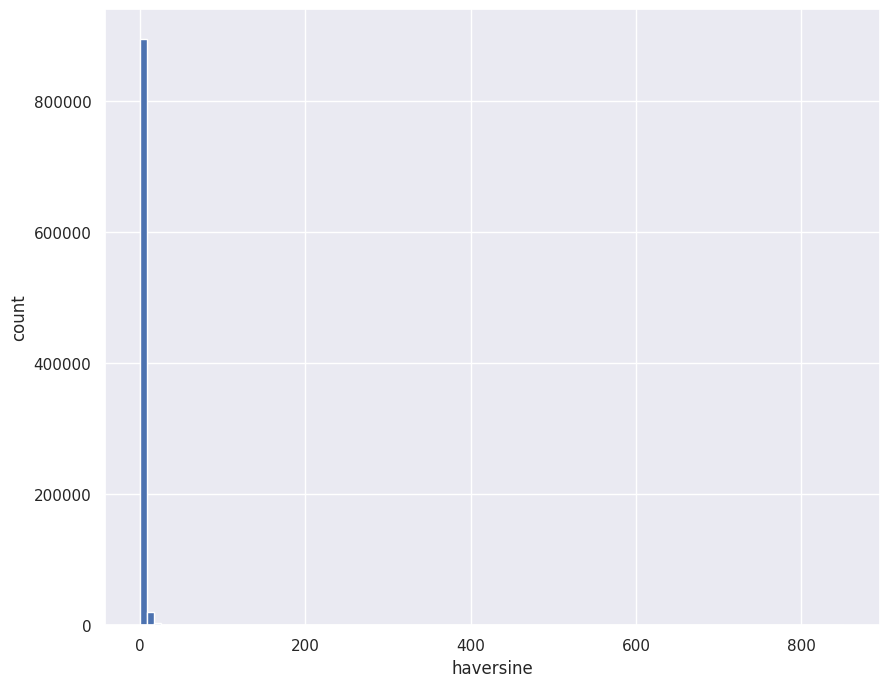

In [124]:
plt.hist(train['haversine'], bins=100)
plt.xlabel('haversine')
plt.ylabel('count')
plt.show()

In [125]:
train = train[(train['haversine'] < train['haversine'].quantile(0.90))]

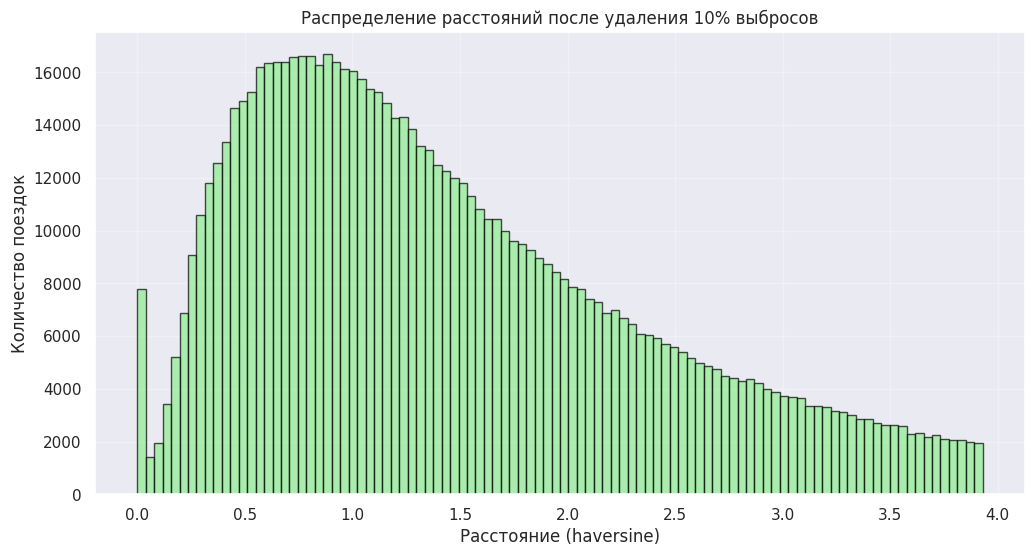

In [126]:
plt.figure(figsize=(12, 6))
plt.hist(train['haversine'], bins=100, alpha=0.7, color='lightgreen', edgecolor='black')
plt.xlabel('Расстояние (haversine)')
plt.ylabel('Количество поездок')
plt.title('Распределение расстояний после удаления 10% выбросов')
plt.grid(alpha=0.3)
plt.show()

In [127]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [128]:
from sklearn.metrics import mean_squared_error
import numpy as np

notnum_feats = ['hour', 'day_of_week', 'month', 'airport_start', 'airport_finish', 'grid_first', 'grid_second']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5732
Test MSE = 0.3285
Train RMSE = 0.5138
Train MSE = 0.2640


/tmp/ipython-input-2165858811.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


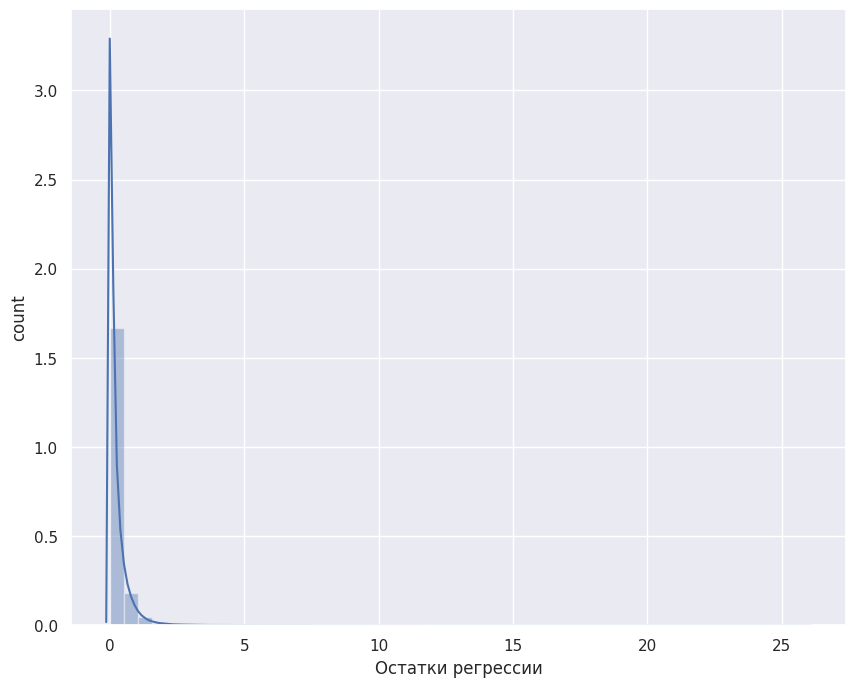

In [129]:
error = (y_train - model.predict(X_train)) ** 2
sns.distplot(error)
plt.xlabel('Остатки регрессии')
plt.ylabel('count')
plt.show()

In [130]:
mask = ((error < np.quantile(error, 0.90)))

In [132]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

# Обучаем на данных с маской
model = pipeline.fit(X_train[mask], y_train[mask])
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

# Предсказываем на тренировочных данных (тоже с маской для consistency)
y_train_pred = model.predict(X_train[mask])
train_mse = mean_squared_error(y_train[mask], y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5710
Test MSE = 0.3260
Train RMSE = 0.3713
Train MSE = 0.1379


/tmp/ipython-input-1036739615.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


<Axes: xlabel='log_trip_duration', ylabel='Density'>

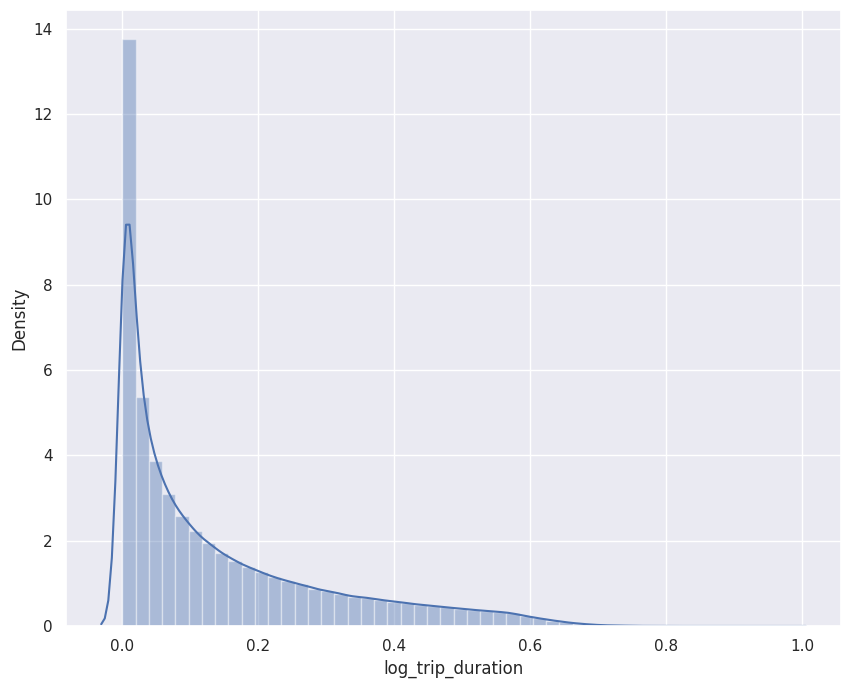

In [133]:
error = (y_train[mask] - model.predict(X_train[mask])) ** 2
sns.distplot(error)

Судя по графикам, выбросов стало значительно меньше.

*Замечание:* У меня получилось, что качество ухудшилось на тестовой выборке, когда мы убрали выбросы. Это может происходить, так как в тестовой выборке также большое количество выбросов.

Сейчас у нас очень много категориальных признаков. В категориальных признаках могут содержаться редкие категории, обычно это плохо: модель сильно переобучается на таких примерах. Попробуйте объединить редкие категории в одну. Естественно, делать это нужно только для действительно редких категорий.

Обучите модель на очищенных данных и посчитайте качество на тестовой выборке.

In [134]:
## напечатаем наши категориальные признаки
notnum_feats

['hour',
 'day_of_week',
 'month',
 'airport_start',
 'airport_finish',
 'grid_first',
 'grid_second']

Из всех этих признаков редкими можно считать 'airport_start' и 'airport_finish'. Попробуем их объединить так: не будем учитывать, что это два разных аэропорта.

In [135]:
train.loc[train['airport_start'] == 2, 'airport_start'] = 1

test.loc[test['airport_start'] == 2, 'airport_start'] = 1

train.loc[train['airport_finish'] == 2, 'airport_finish'] = 1

test.loc[test['airport_finish'] == 2, 'airport_finish'] = 1

In [136]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport_start', 'airport_finish', 'is_slow', 'grid_first', 'grid_second']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [138]:
from sklearn.metrics import mean_squared_error
import numpy as np

notnum_feats = ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad', 'airport_start', 'airport_finish']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5686
Test MSE = 0.3233
Train RMSE = 0.5146
Train MSE = 0.2648


In [139]:
error = (y_train - model.predict(X_train)) ** 2
mask = (error < np.quantile(error, 0.90))

In [141]:
from sklearn.metrics import mean_squared_error
import numpy as np

notnum_feats = ['hour', 'day_of_week', 'month', 'airport_start', 'airport_finish', 'grid_first', 'grid_second']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

# Применяем маску ДО обучения
X_train_masked = X_train[mask]
y_train_masked = y_train[mask]

# Обучаем на данных с маской
model = pipeline.fit(X_train_masked, y_train_masked)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

# Предсказываем на тренировочных данных (с маской)
y_train_pred = model.predict(X_train_masked)
train_mse = mean_squared_error(y_train_masked, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5651
Test MSE = 0.3193
Train RMSE = 0.3715
Train MSE = 0.1380


Попробуем объединить признаки с аэропортами следующим образом: если в маршруте одно из направлений аэропорт, то 1, иначе 0. И мы можем уже учитывать этот признак как численный.

In [142]:
train['airport'] = train['airport_start'] | train['airport_finish']

test['airport'] = test['airport_start'] | test['airport_finish']

In [143]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [146]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Проверим доступные столбцы
available_columns = X_train.columns.tolist()
print("Доступные столбцы:", available_columns)

# Используем только те столбцы, которые действительно есть в данных
notnum_feats = ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']

# Убедимся, что все столбцы существуют
notnum_feats = [col for col in notnum_feats if col in available_columns]
num_feats = [col for col in num_feats if col in available_columns]

print("Используемые категориальные признаки:", notnum_feats)
print("Используемые числовые признаки:", num_feats)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Доступные столбцы: ['hour', 'day_of_year', 'day_of_week', 'month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second']
Используемые категориальные признаки: ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second']
Используемые числовые признаки: ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']
Test RMSE = 0.5868
Test MSE = 0.3443
Train RMSE = 0.5181
Train MSE = 0.2684


In [147]:
error = (y_train - model.predict(X_train)) ** 2
mask = (error < np.quantile(error, 0.90))

In [148]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Используем только существующие столбцы (без 'airport')
notnum_feats = ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

# Применяем маску ДО обучения
X_train_masked = X_train[mask]
y_train_masked = y_train[mask]

# Обучаем на данных с маской
model = pipeline.fit(X_train_masked, y_train_masked)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

# Предсказываем на ТЕХ ЖЕ тренировочных данных (с маской)
y_train_pred = model.predict(X_train_masked)
train_mse = mean_squared_error(y_train_masked, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

# Если хотите обновить исходные данные
X_train = X_train_masked
y_train = y_train_masked

Test RMSE = 0.5751
Test MSE = 0.3307
Train RMSE = 0.3717
Train MSE = 0.1382


*Замечание:* до объединения признаков с аэропортами после кодирования было 6 (два признака по три возможных варианта), а после объединения их стало 2.

**Задание 14 (1 балл)**. После OneHot-кодирования количество признаков в нашем датасете сильно возрастает. Посчитайте колиество признаков до и после кодирования категориальных признаков.

In [149]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']
print("Size before OneHot:", X_train.shape)
print("Size after  OneHot:", column_transformer.transform(X_train).shape)

Size before OneHot: (826994, 10)
Size after  OneHot: (826994, 65)


Попробуйте обучить не `Ridge`-, а `Lasso`-регрессию. Какой метод лучше?

In [151]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

lasso_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso())
])

model = lasso_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.8242
Test MSE = 0.6794
Train RMSE = 0.6706
Train MSE = 0.4497


In [152]:
error = (y_train - model.predict(X_train)) ** 2
mask = (error < np.quantile(error, 0.90))

X_train = X_train[mask]
y_train = y_train[mask]

Разбейте обучающую выборку на обучающую и валидационную в отношении 8:2. По валидационной выборке подберите оптимальные значения параметра регуляризации (по логарифмической сетке) для `Ridge` и `Lasso`, на тестовой выборке измерьте качество лучшей полученной модели.

In [153]:
train, val = train_test_split(train, test_size=0.2)

In [154]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second']]
X_val = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second']]
y_train = train['log_trip_duration']
y_val = test['log_trip_duration']

In [155]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(steps=[
     ('ohe_and_scaling', column_transformer),
     ('regression', Ridge())
 ])

alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(pipeline, [{"regression__alpha": alphas}],
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
searcher.fit(X_val, y_val)

best_alpha1 = searcher.best_params_["regression__alpha"]
print("Best alpha = %.4f" % best_alpha1)

Best alpha = 14.3845


In [157]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

# Убедимся, что best_alpha1 определена
print("best_alpha1 =", best_alpha1)

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge(alpha=best_alpha1))
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

best_alpha1 = 14.38449888287663
Test RMSE = 0.5865
Test MSE = 0.3439
Train RMSE = 0.5172
Train MSE = 0.2675


In [158]:
from sklearn.model_selection import GridSearchCV

lasso_pipeline = Pipeline(steps=[
      ('ohe_and_scaling', column_transformer),
      ('regression', Lasso())
  ])

alphas = np.logspace(-4, 3, 20)
searcher = GridSearchCV(lasso_pipeline, [{"regression__alpha": alphas}],
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
searcher.fit(X_val, y_val)

best_alpha_lasso1 = searcher.best_params_["regression__alpha"]
print("Best alpha = %.4f" % best_alpha_lasso1)

Best alpha = 0.0001


In [159]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

# Убедимся, что best_alpha_lasso1 определена
print("best_alpha_lasso1 =", best_alpha_lasso1)

lasso_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso(alpha=best_alpha_lasso1))  # добавил alpha=
])

model = lasso_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

best_alpha_lasso1 = 0.0001
Test RMSE = 0.5864
Test MSE = 0.3438
Train RMSE = 0.5173
Train MSE = 0.2676


Lasso явно улучшилось, а Ridge почему-то совсем немного. Но в итоге метрики получились практически одинаковыми для Ridge и Lasso.

Для каждого перебранного `alpha` для Lasso посчитайте количество нулевых весов в модели и нарисуйте график зависимости его от `alpha`. Как сильно придётся потерять в качестве, если мы хотим с помощью Lasso избавиться хотя бы от половины признаков?

In [161]:
count_of_zs = pd.DataFrame(columns=['alpha', 'count'])

for alpha in np.logspace(-4, 3, 20):
    column_transformer = ColumnTransformer([
        ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
        ('scaling', StandardScaler(), num_feats)
    ])

    lasso_pipeline = Pipeline(steps=[
        ('ohe_and_scaling', column_transformer),
        ('regression', Lasso(alpha=alpha))  # добавил alpha=
    ])

    model = lasso_pipeline.fit(X_train, y_train)

    to_add = {'alpha': alpha, 'count': sum(model.named_steps['regression'].coef_ == 0)}

    count_of_zs = pd.concat([count_of_zs, pd.DataFrame([to_add])], ignore_index=True)

# Выведем результаты
print(count_of_zs)

/tmp/ipython-input-119628651.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  count_of_zs = pd.concat([count_of_zs, pd.DataFrame([to_add])], ignore_index=True)


          alpha count
0      0.000100     7
1      0.000234    11
2      0.000546    12
3      0.001274    26
4      0.002976    41
5      0.006952    57
6      0.016238    61
7      0.037927    63
8      0.088587    64
9      0.206914    64
10     0.483293    65
11     1.128838    65
12     2.636651    65
13     6.158482    65
14    14.384499    65
15    33.598183    65
16    78.475997    65
17   183.298071    65
18   428.133240    65
19  1000.000000    65


Text(17.319444444444443, 0.5, 'count')

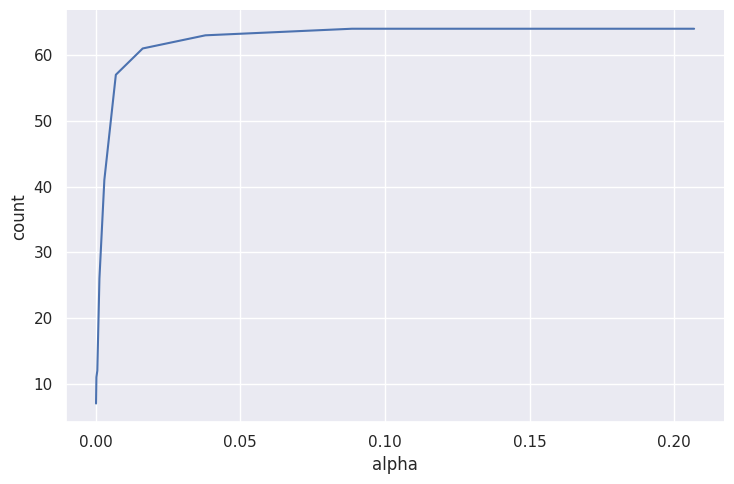

In [162]:
x = count_of_zs['alpha'].head(10)
y = count_of_zs['count'].head(10)

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('alpha')
plt.ylabel('count')

In [163]:
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

lasso_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Lasso(best_alpha_lasso1))
])

model = lasso_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(np.square(mean_squared_error(y_test, y_pred)))

0.1182202869860388


<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Задание 15 (1 балл)**. Часто бывает полезным использовать взаимодействия признаков (feature interactions), то есть строить новые признаки на основе уже существующих. Выше мы разбили карту Манхэттена на ячейки и придумали признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка".

Давайте попробуем сделать следующее: посчитаем, сколько раз встречается каждая возможная пара этих признаков в нашем датасете и выберем 100 самых частых пар. Закодируем поездки с этими частыми парами как категориальный признак, остальным объектам припишем -1. Получается, что мы закодировали, откуда и куда должно было ехать такси.

Также можете придумать ещё какой-нибудь способ сделать признаки про маршрут. Если эти признаки будут давать хороший прирост в качестве, то за это могут быть даны дополнительные бонусные баллы.

**Вопрос**: Почему такой признак потенциально полезный? Почему линейная модель не может самостоятельно "вытащить" эту информацию, ведь у нее в распоряжении есть признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка"?

**Ответ:** Признак полезный, так как если таких поездок много в обучающих данных, то скорее всего это распространенные поездки => их будет много и в тестовых данных. Линейная модель не может это вытащить, так как это нелинейная зависимость грубо говоря. Получается, что то, откуда началась поездка и где закончилась, - это отдельные признаки, и наша модель их не комбинирует между, а маршрут (т. е. комбинация этих двух признаков) - это уже новый целый признак.

In [164]:
train['top100'] = -1
train['route'] = train['grid_first'].astype(str) + ', ' + train['grid_second'].astype(str)

test['top100'] = -1
test['route'] = test['grid_first'].astype(str) + ', ' + test['grid_second'].astype(str)

In [165]:
# сто самых частых частых пар будут последними после сортировки
komb_grid = train[(train['route'] != 'nan, nan') & (train['route'] != '-1, -1')].groupby(['route']).count().sort_values('id').tail(100)

In [166]:
train.loc[train['route'].isin(komb_grid.index), 'top100'] = train['route']

test.loc[test['route'].isin(komb_grid.index), 'top100'] = test['route']

/tmp/ipython-input-33234139.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['8, 8' '5, 6' '-1, 8' ... '8, 5' '-1, 7' '7, 5']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train.loc[train['route'].isin(komb_grid.index), 'top100'] = train['route']
/tmp/ipython-input-33234139.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['8, 8' '5, -1' '-1, 6' ... '8, 6' '8, 3' '-1, 8']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[test['route'].isin(komb_grid.index), 'top100'] = test['route']


In [167]:
train['top100'] = train['top100'].astype(str)

test['top100'] = test['top100'].astype(str)

le = LabelEncoder()
train['top100'] = le.fit_transform(train['top100'])
test['top100'] = le.fit_transform(test['top100'])

Заново обучите модель (`Ridge`, если она дала более высокое качество в предыдущих экспериментах, и `Lasso` иначе) на новых даннных и посчитайте качество на тестовой выборке

In [168]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second', 'top100']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second', 'top100']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [169]:
notnum_feats = ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second', 'top100']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad', 'airport']

In [170]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5301
Test MSE = 0.2810
Train RMSE = 0.4901
Train MSE = 0.2402


In [171]:
error = (y_train - model.predict(X_train)) ** 2
mask = (error < np.quantile(error, 0.90))

In [172]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

# Применяем маску ДО обучения
X_train_masked = X_train[mask]
y_train_masked = y_train[mask]

# Обучаем на данных с маской
model = pipeline.fit(X_train_masked, y_train_masked)
y_pred = model.predict(X_test)

# ВЫЧИСЛЯЕМ БЕЗ squared=False
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

# Предсказываем на ТЕХ ЖЕ тренировочных данных (с маской)
y_train_pred = model.predict(X_train_masked)
train_mse = mean_squared_error(y_train_masked, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5293
Test MSE = 0.2801
Train RMSE = 0.3451
Train MSE = 0.1191


In [174]:
train.drop('route', axis=1,inplace=True)

test.drop('route', axis=1,inplace=True)

KeyError: "['route'] not found in axis"

**Задание 16 (бонус, 1 балл)**. Где, как не для нашей задачи, считать манхэттенское расстояние?

**Вопрос**: Найдите, что такое манхэттенское расстояние и почему оно так называется. Как оно нам может помочь?

Введите систему координат на нашей карте так, чтобы оси были параллельны улицам Манхэттена, и добавьте сначала в данные признак "манхэттенское расстояние между пунктом отправления и пунктом назначения", а затем и логарифм этого признака. Посчитайте корреляцию между вашим новыми признаком и таргетом; между `log_haversine` и таргетом. В каком случае корреляция больше?

Нарисуйте карту, где покажете выбранные оси. Чтобы мы могли проверить вашу работу, просьба сделать скрин этой карты и приложить картинку (если мы откроем ваш ноутбук, виджеты отображаться не будут).

**Ответ:** Манхэттенское расстояние -  метрика, введённая Германом Минковским. Согласно этой метрике, расстояние между двумя точками равно сумме модулей разностей их координат.

Оно названо так потому, что это расстояние, которое автомобиль мог бы проехать в городе, состоящем из квадратных кварталов, таких как Манхэттен.

Посмторим, как оно будет приближать наш таргет, так как тут расстояние высчитывается по определенному правилу, и может что-то поменяться.

In [175]:
from scipy.spatial import distance
from scipy. spatial.distance import cityblock

In [ ]:
# show_circles_on_map(df_train.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

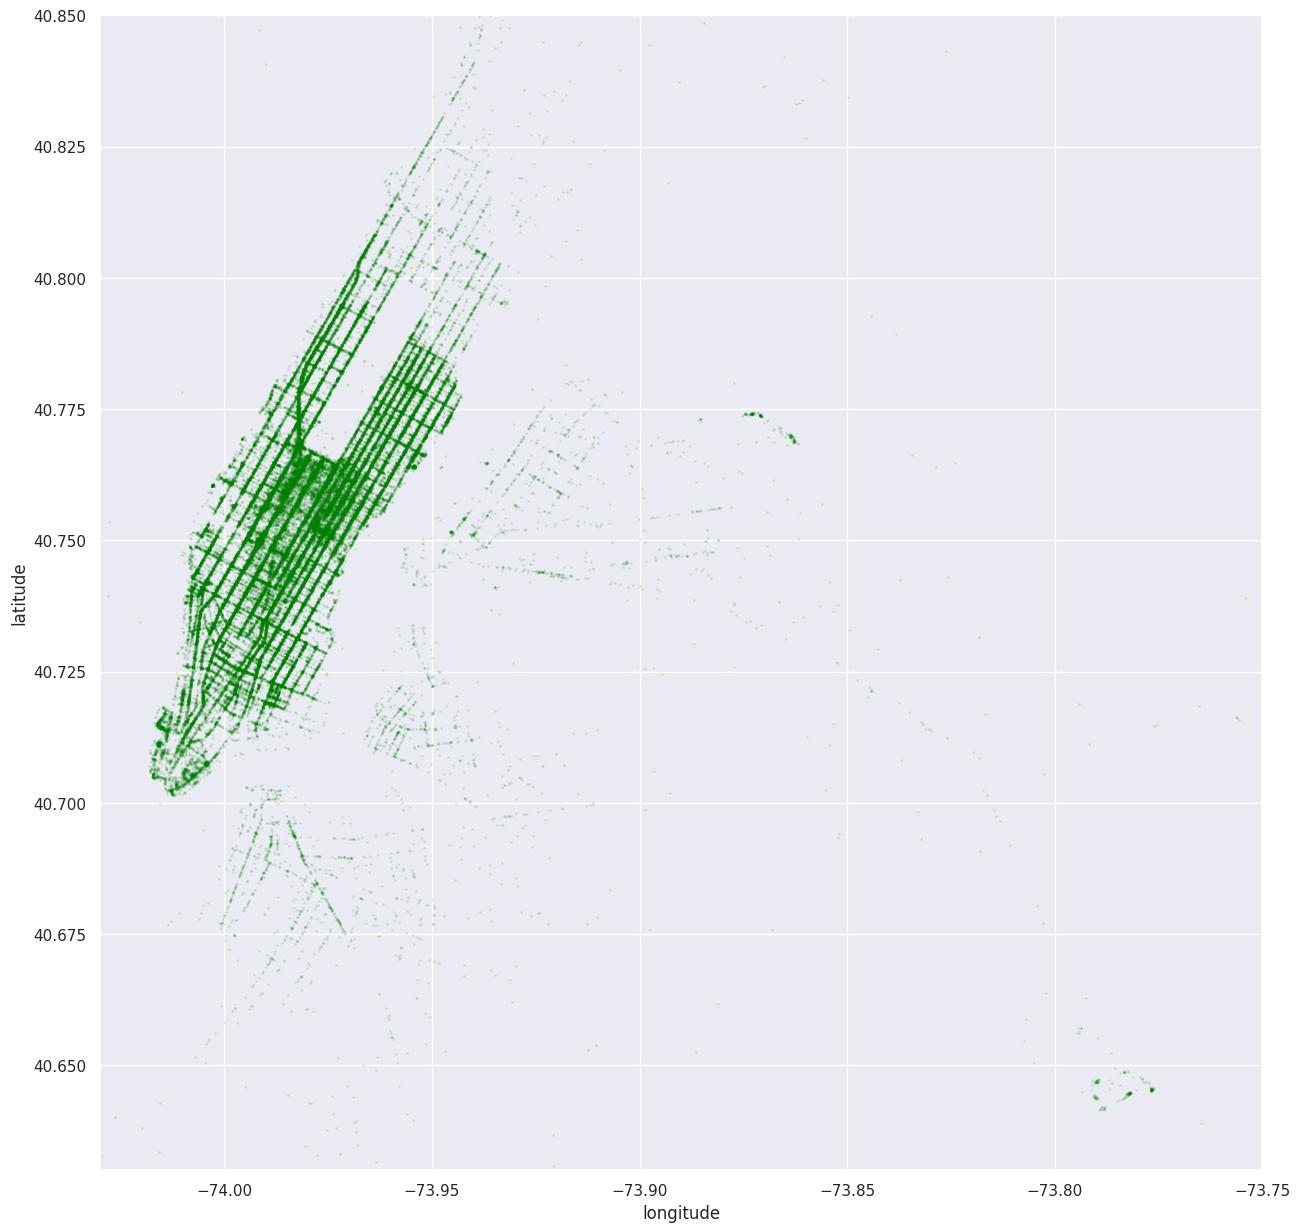

In [176]:
N = 100000
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)
plt.figure(figsize=(15,15))
plt.scatter(train['pickup_longitude'].values[:N], train['pickup_latitude'].values[:N],
              color='green', s=1, label='train', alpha=0.1)
plt.ylabel('latitude')
plt.xlabel('longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)
plt.show()

Выберем точки для построения осей:


In [177]:
start = tuple([40.7834, -73.9662])
X_ = tuple([40.778612, -73.954188])
Y_ = tuple([40.799285, -73.954644])

In [178]:
def manh_dist(lat1, lon1, lat2, lon2):
  l = np.array([
      abs(lat1 - lon1),
      abs(lat2 - lon2)
  ])
  return l[0] + l[1]

Посчитаем координаты в новой системе координат для всех точек. Тут я пользуюсь математикой: мы поворачиваем на 37 градусов (это я высчитала через направляющие векторы старой и новой системы координат). По этим формулам считаем новые координаты:

x = X cos α— Y sin α + a

y = X sin α + Y cos α + b

In [179]:
train['pickup_latitude_new'] = (train['pickup_longitude'] * (0.6084290565) + train['pickup_latitude'] * (0.7936082681) + start[1])
train['pickup_longitude_new'] = (train['pickup_longitude'] * (0.7936082681) - train['pickup_latitude'] * (0.6084290565) + start[0])
train['dropoff_latitude_new'] = (train['dropoff_longitude'] * (0.6084290565) + train['dropoff_latitude'] * (0.7936082681) + start[1])
train['dropoff_longitude_new'] = (train['dropoff_longitude'] * (0.7936082681) - train['dropoff_latitude'] * (0.6084290565) + start[0])

test['pickup_latitude_new'] = (test['pickup_longitude'] * (0.6084290565) + test['pickup_latitude'] * (0.7936082681) + start[1])
test['pickup_longitude_new'] = (test['pickup_longitude'] * (0.7936082681) - test['pickup_latitude'] * (0.6084290565) + start[0])
test['dropoff_latitude_new'] = (test['dropoff_longitude'] * (0.6084290565) + test['dropoff_latitude'] * (0.7936082681) + start[1])
test['dropoff_longitude_new'] = (test['dropoff_longitude'] * (0.7936082681) - test['dropoff_latitude'] * (0.6084290565) + start[0])
train['pickup_longitude_new'].max()

-30.922662651098364

In [180]:
train['manh_dist'] = manh_dist(train['pickup_latitude_new'], train['pickup_longitude_new'], train['dropoff_latitude_new'], train['dropoff_longitude_new'])
train['log_manh_dist'] = np.log1p(train['manh_dist'])

test['manh_dist'] = manh_dist(test['pickup_latitude_new'], test['pickup_longitude_new'], test['dropoff_latitude_new'], test['dropoff_longitude_new'])
test['log_manh_dist'] = np.log1p(test['manh_dist'])

train

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,log_trip_duration,...,grid_first,grid_second,airport,top100,pickup_latitude_new,pickup_longitude_new,dropoff_latitude_new,dropoff_longitude_new,manh_dist,log_manh_dist
559921,id1032014,1,2016-03-14 21:26:17,5,-73.984924,40.744946,-73.989395,40.759605,0,6.342121,...,8,8,0,100,-86.645252,-42.722056,-86.636338,-42.734524,87.825010,4.486668
1295906,id0099579,0,2016-03-14 17:18:46,1,-73.969673,40.785526,-73.947792,40.776215,0,6.320768,...,5,6,0,66,-86.603768,-42.734643,-86.597844,-42.711613,87.755355,4.485884
381043,id3161053,1,2016-03-13 15:52:42,1,-74.002220,40.719509,-73.982491,40.757511,0,6.830874,...,-1,8,0,10,-86.675962,-42.720306,-86.633799,-42.727770,87.861684,4.487081
140901,id3062227,0,2016-06-05 18:22:26,2,-73.975014,40.741844,-73.960876,40.761372,0,5.602119,...,8,5,0,97,-86.641683,-42.712304,-86.617585,-42.712966,87.833998,4.486769
1432983,id2630411,1,2016-03-10 13:28:14,1,-73.996040,40.753815,-73.995834,40.749004,0,5.459586,...,7,7,0,88,-86.644977,-42.736274,-86.648669,-42.733184,87.824187,4.486659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607111,id0896173,0,2016-04-08 14:02:12,1,-73.995628,40.739243,-74.005447,40.739204,0,6.282267,...,7,7,0,88,-86.656291,-42.727081,-86.662295,-42.734851,87.856654,4.487024
994016,id1257583,1,2016-05-11 18:18:54,6,-73.954353,40.789791,-73.951714,40.772957,0,6.311735,...,6,6,0,77,-86.591062,-42.725080,-86.602816,-42.712743,87.756054,4.485892
392043,id3782016,0,2016-06-24 22:43:15,2,-73.984177,40.750801,-73.981323,40.764484,0,6.495266,...,8,5,0,97,-86.640150,-42.725026,-86.627555,-42.731087,87.811593,4.486517
744675,id1067734,0,2016-02-13 23:55:06,1,-73.993073,40.728012,-74.000351,40.738071,0,5.926926,...,-1,7,0,9,-86.663648,-42.718220,-86.660093,-42.730117,87.875405,4.487235


In [181]:
train.loc[:,['log_manh_dist','log_trip_duration','manh_dist']].corr().iloc[[0,2],[1]]

,log_trip_duration
log_manh_dist,0.065162
manh_dist,0.064306


In [182]:
train.loc[:,['log_haversine','log_trip_duration','manh_dist']].corr().iloc[[0,2],[1]]

,log_trip_duration
log_haversine,0.576193
manh_dist,0.064306


Карта в новой системе координат:

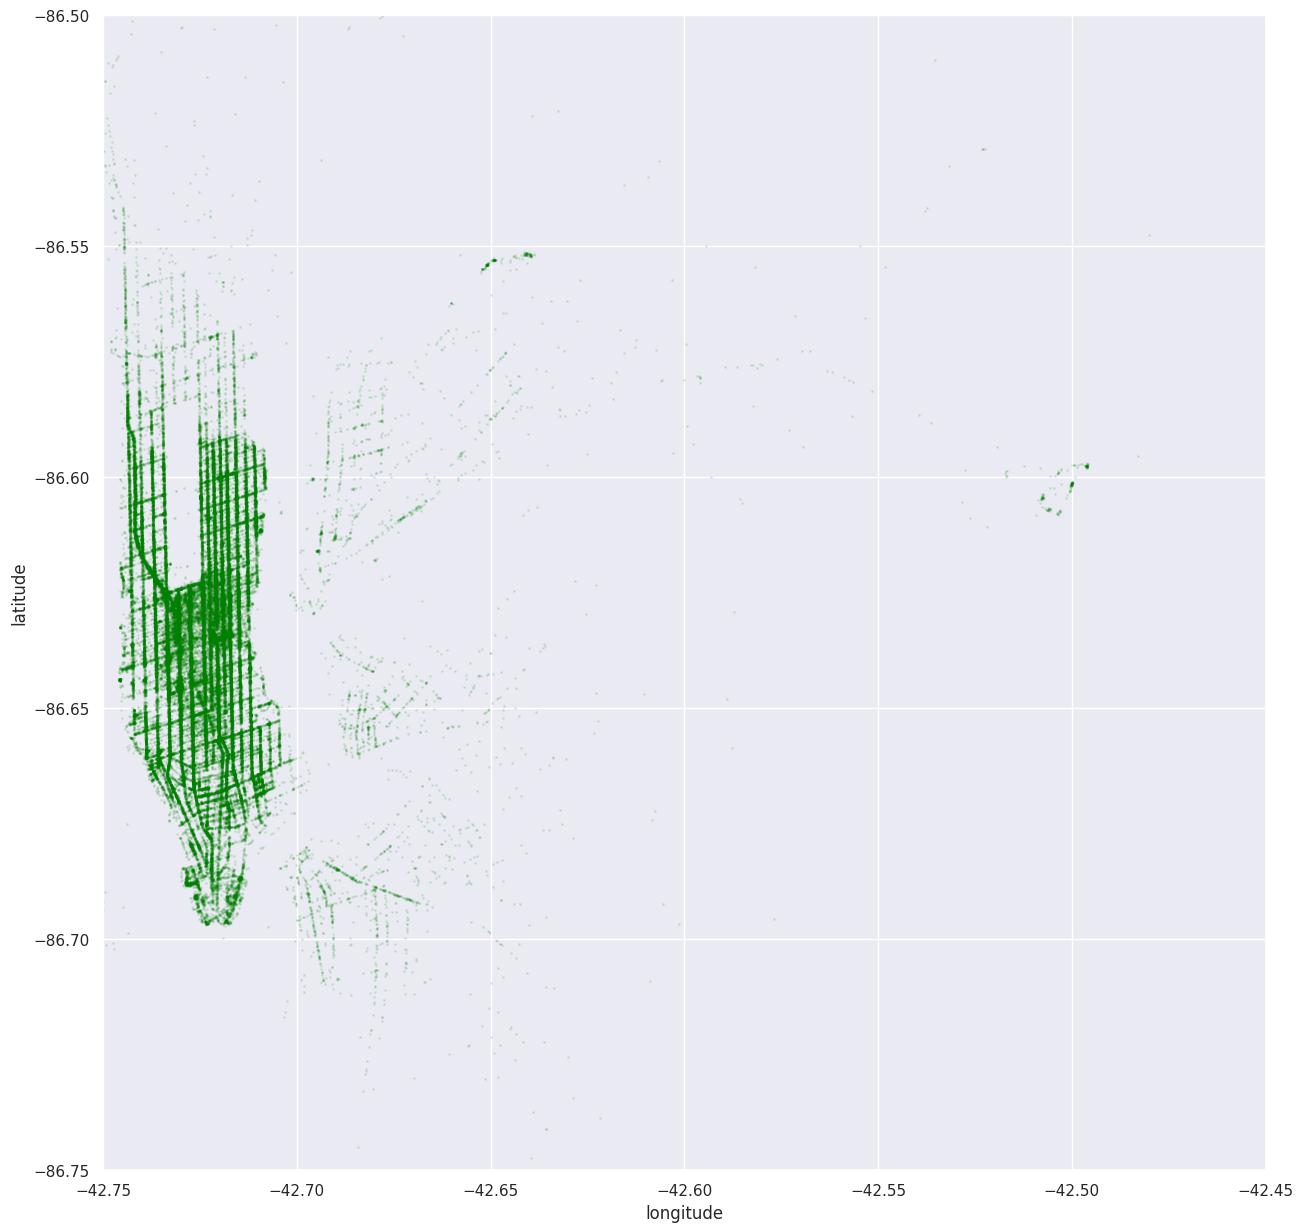

In [183]:
N = 100000
city_long_border = (-42.75, -42.45)
city_lat_border = (-86.75, -86.5)
plt.figure(figsize=(15,15))
plt.scatter(train['pickup_longitude_new'].values[:N], train['pickup_latitude_new'].values[:N],
              color='green', s=1, label='train', alpha=0.1)
plt.ylabel('latitude')
plt.xlabel('longitude')
plt.ylim(city_lat_border)
plt.xlim(city_long_border)
plt.show()

In [184]:
map = show_circles_on_map(train.sample(10), "pickup_latitude", "pickup_longitude", "blue")

line_y = list()
line_y.append(start)
line_y.append(Y_)
folium.PolyLine(line_y, color = 'red', weight=5).add_to(map)

folium.Marker(start).add_to(map)
line_x = list()
line_x.append(start)
line_x.append(X_)
folium.PolyLine(line_x, color = 'red', weight=5).add_to(map)

map

Заново обучите модель на новых даннных и посчитайте качество на тестовой выборке. Стало ли лучше? Объясните полученный результат.

Обучим с manh_dist.

In [185]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second', 'top100', 'manh_dist']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second', 'top100', 'manh_dist']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [186]:
notnum_feats = ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second', 'top100']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad', 'airport', 'manh_dist']

In [187]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)


test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5299
Test MSE = 0.2808
Train RMSE = 0.4901
Train MSE = 0.2402


In [188]:
error = (y_train - model.predict(X_train)) ** 2
mask = (error < np.quantile(error, 0.90))

In [189]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

# Применяем маску
X_train_masked = X_train[mask]
y_train_masked = y_train[mask]

# Обучаем на данных с маской
model = pipeline.fit(X_train_masked, y_train_masked)
y_pred = model.predict(X_test)

# ПРАВИЛЬНЫЙ РАСЧЕТ METРИК
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

# Предсказываем на тренировочных данных (только на masked)
y_train_pred = model.predict(X_train_masked)
train_mse = mean_squared_error(y_train_masked, y_train_pred)
train_rmse = np.sqrt(train_mse)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5289
Test MSE = 0.2797
Train RMSE = 0.3451
Train MSE = 0.1191


Обучим с log_manh_dist.

In [190]:
X_train = train.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second', 'top100', 'log_manh_dist']]
X_test = test.drop(['log_trip_duration'], axis=1)[['hour', 'day_of_year', 'day_of_week','month', 'is_bad', 'log_haversine', 'airport', 'is_slow', 'grid_first', 'grid_second', 'top100', 'log_manh_dist']]
y_train = train['log_trip_duration']
y_test = test['log_trip_duration']

In [191]:
notnum_feats = ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second', 'top100']
num_feats = ['day_of_year', 'log_haversine', 'is_slow', 'is_bad', 'airport', 'log_manh_dist']

In [192]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

model = pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ПРАВИЛЬНЫЙ РАСЧЕТ - БЕЗ squared=False
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mse = mean_squared_error(y_test, y_pred)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

y_train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mse = mean_squared_error(y_train, y_train_pred)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5299
Test MSE = 0.2808
Train RMSE = 0.4901
Train MSE = 0.2402


In [193]:
error = (y_train - model.predict(X_train)) ** 2
mask = (error < np.quantile(error, 0.90))

In [194]:
from sklearn.metrics import mean_squared_error
import numpy as np

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('regression', Ridge())
])

# Обучаем на данных с маской
model = pipeline.fit(X_train[mask], y_train[mask])
y_pred = model.predict(X_test)

# ✅ ПРАВИЛЬНО - используем np.sqrt() вместо squared=False
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mse = mean_squared_error(y_test, y_pred)
print("Test RMSE = %.4f" % test_rmse)
print("Test MSE = %.4f" % test_mse)

# Предсказываем на тренировочных данных
y_train_pred = model.predict(X_train[mask])
train_rmse = np.sqrt(mean_squared_error(y_train[mask], y_train_pred))
train_mse = mean_squared_error(y_train[mask], y_train_pred)
print("Train RMSE = %.4f" % train_rmse)
print("Train MSE = %.4f" % train_mse)

Test RMSE = 0.5288
Test MSE = 0.2796
Train RMSE = 0.3451
Train MSE = 0.1191


Качество модели не стало лучше,так как эти признаки не особо хорошо коррелируют с таргетом. Но с логарифмом манхэттенского расстояния получилось чуть лучше, потому что он коррелирует лучше, чем просто манхэттенское расстояние.




**Задание 17 (бонус, 2 балла)**. Реализуйте трансформер, который строит разбиение карты по шестигранной решётке с помощью библиотеки [H3](https://github.com/uber/h3-py) и вычисляет признаки на основе такого разбиения.

Признаки могут быть самые разные: расстояние между точкой старта и финиша, посчитанное в количестве шестиугольников; статистика по числу поездок и по их продолжительности в соседних шестиугольниках.

Важно: производительность библиотеки существенно зависит от количества шестиугольников на карте (определяется параметром resolution). Подберите такое разрешение, при котором ваш код будет работать за приемлемое время.

При построении признаков старайтесь не допустить утечки целевой переменной (подробнее про это можно почитать в материалах 1-го семинара) — в противном случае хорошего качества на тестовой выборке достичь не получится.

Измерьте качество после добавления новых признаков. За улучшение функционала ошибки на каждые 0.005 на тестовой выборке будет даваться 0.5 бонусных балла. Можно получить до 2 бонусных баллов за это задание.

In [208]:
import h3
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from collections import Counter

class SimpleH3FeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, resolution=6):
        self.resolution = resolution
        self.hexagon_stats_ = None

    def lat_lng_to_h3(self, lat, lng):
        return h3.latlng_to_cell(lat, lng, self.resolution)

    def fit(self, X, y=None):
        global train
        pickup_hexagons = train.apply(lambda row: self.lat_lng_to_h3(
            row['pickup_latitude_new'], row['pickup_longitude_new']), axis=1)

        hexagon_counts = Counter(pickup_hexagons)
        self.hexagon_stats_ = {'popularity': hexagon_counts}
        return self

    def transform(self, X):
        X_transformed = X.copy()
        global train, test

        if len(X) == len(train):
            coords_df = train
        else:
            coords_df = test

        # Только самые важные признаки
        pickup_hexagons = coords_df.apply(lambda row: self.lat_lng_to_h3(
            row['pickup_latitude_new'], row['pickup_longitude_new']), axis=1)

        dropoff_hexagons = coords_df.apply(lambda row: self.lat_lng_to_h3(
            row['dropoff_latitude_new'], row['dropoff_longitude_new']), axis=1)

        # Только 2 признака вместо 5
        if self.hexagon_stats_:
            X_transformed['pickup_hexagon_popularity'] = pickup_hexagons.map(
                lambda x: self.hexagon_stats_['popularity'].get(x, 0))

        # Расстояние в шестиугольниках
        X_transformed['hexagon_distance'] = [h3.grid_distance(pickup, dropoff)
                                           for pickup, dropoff in zip(pickup_hexagons, dropoff_hexagons)]

        return X_transformed

# Базовые признаки
available_columns = X_train.columns.tolist()
notnum_feats = [col for col in ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second'] if col in available_columns]
num_feats = [col for col in ['day_of_year', 'log_haversine', 'is_slow', 'is_bad'] if col in available_columns]

print("Используемые категориальные признаки:", notnum_feats)
print("Используемые числовые признаки:", num_feats)

# Базовый пайплайн (без H3)
base_preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
    ('scaling', StandardScaler(), num_feats)
])

base_pipeline = Pipeline([
    ('preprocessing', base_preprocessor),
    ('regression', Ridge())
])

print("\nОбучаем базовую модель...")
base_model = base_pipeline.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
print(f"Базовая модель - Test RMSE: {base_rmse:.4f}")

# Тестируем разные разрешения H3 с упрощенными признаками
resolutions = [5, 6, 7]
best_rmse = base_rmse
best_resolution = None
results = []

for resolution in resolutions:
    print(f"\nТестируем разрешение H3: {resolution}")

    try:
        # Только 2 H3 признака
        h3_features_to_add = ['pickup_hexagon_popularity', 'hexagon_distance']

        final_num_feats = num_feats + [feat for feat in h3_features_to_add if feat not in num_feats]

        h3_preprocessor = ColumnTransformer([
            ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
            ('scaling', StandardScaler(), final_num_feats)
        ])

        h3_pipeline = Pipeline([
            ('h3_features', SimpleH3FeaturesTransformer(resolution=resolution)),
            ('preprocessing', h3_preprocessor),
            ('regression', Ridge())
        ])

        # Обучаем и оцениваем
        h3_model = h3_pipeline.fit(X_train, y_train)
        y_pred_h3 = h3_model.predict(X_test)
        h3_rmse = np.sqrt(mean_squared_error(y_test, y_pred_h3))

        results.append({'resolution': resolution, 'rmse': h3_rmse})
        print(f"Resolution {resolution}: RMSE = {h3_rmse:.4f}")

        if h3_rmse < best_rmse:
            best_rmse = h3_rmse
            best_resolution = resolution

    except Exception as e:
        print(f"Ошибка при resolution {resolution}: {e}")
        results.append({'resolution': resolution, 'rmse': None})

# Итоговые результаты
print("\n" + "="*50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print(f"Базовый RMSE: {base_rmse:.4f}")

if best_resolution and best_rmse < base_rmse:
    improvement = base_rmse - best_rmse
    print(f"Лучший RMSE с H3 (resolution={best_resolution}): {best_rmse:.4f}")
    print(f"Улучшение: {improvement:.4f}")

    # Расчет бонусных баллов
    bonus_points = min(2.0, (improvement // 0.005) * 0.5)
    print(f"Предполагаемые бонусные баллы: {bonus_points:.1f}")

    # Финальная модель
    print(f"\nСоздаем финальную модель с resolution={best_resolution}")

    h3_features_to_add = ['pickup_hexagon_popularity', 'hexagon_distance']
    final_num_feats = num_feats + [feat for feat in h3_features_to_add if feat not in num_feats]

    final_preprocessor = ColumnTransformer([
        ('ohe', OneHotEncoder(handle_unknown="ignore"), notnum_feats),
        ('scaling', StandardScaler(), final_num_feats)
    ])

    final_pipeline = Pipeline([
        ('h3_features', SimpleH3FeaturesTransformer(resolution=best_resolution)),
        ('preprocessing', final_preprocessor),
        ('regression', Ridge())
    ])

    final_model = final_pipeline.fit(X_train, y_train)

    y_train_pred_final = final_model.predict(X_train)
    y_test_pred_final = final_model.predict(X_test)

    train_rmse_final = np.sqrt(mean_squared_error(y_train, y_train_pred_final))
    test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_pred_final))

    print(f"Финальная модель - Train RMSE: {train_rmse_final:.4f}")
    print(f"Финальная модель - Test RMSE: {test_rmse_final:.4f}")

else:
    print("H3 признаки не улучшили качество модели")
    print("Рекомендации:")
    print("1. Попробуйте другие разрешения: [4, 5, 6]")
    print("2. Увеличьте регуляризацию в Ridge (alpha)")
    print("3. Используйте только один H3 признак")

# Сводка по всем разрешениям
print("\nСводка по всем разрешениям:")
for result in results:
    if result['rmse'] is not None:
        improvement = base_rmse - result['rmse']
        status = "✓ УЛУЧШЕНИЕ" if improvement > 0 else "✗ УХУДШЕНИЕ"
        print(f"Resolution {result['resolution']}: RMSE = {result['rmse']:.4f} ({status}: {improvement:+.4f})")
    else:
        print(f"Resolution {result['resolution']}: Ошибка")

Используемые категориальные признаки: ['hour', 'day_of_week', 'month', 'grid_first', 'grid_second']
Используемые числовые признаки: ['day_of_year', 'log_haversine', 'is_slow', 'is_bad']

Обучаем базовую модель...
Базовая модель - Test RMSE: 0.5865

Тестируем разрешение H3: 5
Resolution 5: RMSE = 0.5844

Тестируем разрешение H3: 6
Resolution 6: RMSE = 0.5852

Тестируем разрешение H3: 7
Resolution 7: RMSE = 0.6109

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
Базовый RMSE: 0.5865
Лучший RMSE с H3 (resolution=5): 0.5844
Улучшение: 0.0021
Предполагаемые бонусные баллы: 0.0

Создаем финальную модель с resolution=5
Финальная модель - Train RMSE: 0.5169
Финальная модель - Test RMSE: 0.5844

Сводка по всем разрешениям:
Resolution 5: RMSE = 0.5844 (✓ УЛУЧШЕНИЕ: +0.0021)
Resolution 6: RMSE = 0.5852 (✓ УЛУЧШЕНИЕ: +0.0013)
Resolution 7: RMSE = 0.6109 (✗ УХУДШЕНИЕ: -0.0244)


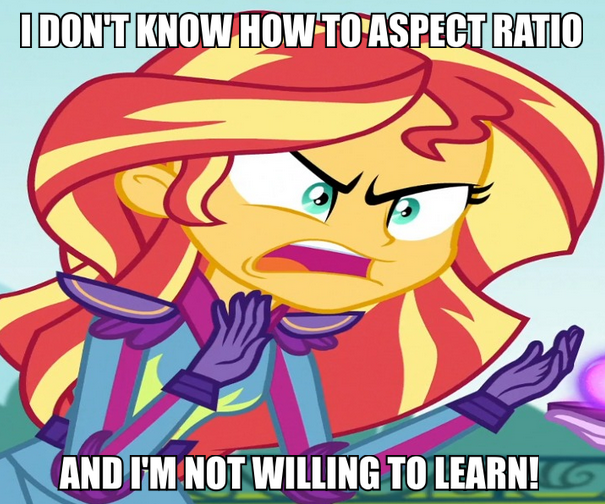